# Research Paper Notebook: Disclosure Timing as a Public Risk Signal in China's A-share Market

**Research question.** Do publicly observable annual-report disclosure schedules contain incremental information about bad news and announcement-window downside risk beyond standard financial fundamentals?

This paper reframes the earlier ST-prediction exercise into an economics question about strategic disclosure and market information processing. Existing studies show that firms may time annual-report disclosure strategically. The contribution here is more operational: using only free AkShare stock-market data, the paper tests whether disclosure-timing behavior is a real-time, publicly observable risk signal with out-of-sample predictive value and economic value.

All outputs from this notebook are isolated under:

`final/improved_version_disclosure_timing/output/`

## Literature Positioning and Contribution

This paper is motivated by the disclosure-timing literature. Prior work on China has documented that good-news firms tend to disclose annual reports earlier and bad-news firms later, and more recent studies examine annual-report timing, within-industry herding, and crash risk. Therefore, the novelty of this paper is **not** claiming that strategic disclosure timing is a new phenomenon.

The contribution is a course-appropriate data-science extension: transform the A-share annual-report appointment system into a public, real-time signal and test whether it has incremental predictive and economic value beyond lagged fundamentals. This follows the logic of the course examples: use a nonstandard public data source, validate it out of sample, connect it to market outcomes, and quantify practical value.

In [1]:
# Cell 1: Environment, paths, and reproducibility
import os
import re
import time
import json
import math
import pickle
import random
import sys
import warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
from matplotlib import font_manager
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import sklearn
from lightgbm import LGBMClassifier
import lightgbm as lgb
import statsmodels.formula.api as smf
import statsmodels

import akshare as ak

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

for key in ["http_proxy", "https_proxy", "HTTP_PROXY", "HTTPS_PROXY", "all_proxy", "ALL_PROXY"]:
    os.environ.pop(key, None)

cwd = Path.cwd().resolve()
project_root = None
for candidate in [cwd, *cwd.parents]:
    possible_roots = []
    if candidate.name == "improved_version_disclosure_timing":
        possible_roots.append(candidate)
    possible_roots.append(candidate / "final" / "improved_version_disclosure_timing")
    for possible_root in possible_roots:
        if (possible_root / "raw" / "raw_financial_panel.csv").exists():
            project_root = possible_root
            break
    if project_root is not None:
        break
if project_root is None:
    raise FileNotFoundError("Cannot locate final/improved_version_disclosure_timing/raw/raw_financial_panel.csv from the current working directory.")

repo_root = project_root.parents[1]
old_financial_path = project_root / "raw" / "raw_financial_panel.csv"

project_dir = project_root / "output"
raw_dir = project_dir / "raw"
price_dir = raw_dir / "prices"
intermediate_dir = project_dir / "intermediate"
figures_dir = project_dir / "figures"
tables_dir = project_dir / "tables"
models_dir = project_dir / "models"
docs_dir = project_dir / "docs"

for p in [project_dir, raw_dir, price_dir, intermediate_dir, figures_dir, tables_dir, models_dir, docs_dir]:
    p.mkdir(parents=True, exist_ok=True)

for font_path in [
    Path("/System/Library/Fonts/Supplemental/Times New Roman.ttf"),
    Path("/System/Library/Fonts/Supplemental/Times New Roman Bold.ttf"),
    Path("/System/Library/Fonts/Supplemental/Times New Roman Italic.ttf"),
    Path("/System/Library/Fonts/Supplemental/Times New Roman Bold Italic.ttf"),
]:
    if font_path.exists():
        font_manager.fontManager.addfont(str(font_path))

sns.set_theme(style="whitegrid", font="Times New Roman")
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.serif": ["Times New Roman"],
    "font.sans-serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "figure.dpi": 120,
})

FISCAL_YEARS = list(range(2019, 2024))
EVENT_MAX = int(os.environ.get("DISCLOSURE_EVENT_MAX", "240"))

print("Repository:", repo_root)
print("Improved project root:", project_root)
print("AkShare version:", ak.__version__)
print("Financial panel:", old_financial_path)
print("Project output directory:", project_dir)
print("Fiscal years:", FISCAL_YEARS)
print("Event-study cap:", EVENT_MAX)

software_versions = pd.DataFrame([
    {"package": "Python", "version": sys.version.split()[0]},
    {"package": "AkShare", "version": ak.__version__},
    {"package": "Pandas", "version": pd.__version__},
    {"package": "NumPy", "version": np.__version__},
    {"package": "Scikit-learn", "version": sklearn.__version__},
    {"package": "LightGBM", "version": lgb.__version__},
    {"package": "Statsmodels", "version": statsmodels.__version__},
    {"package": "Matplotlib", "version": matplotlib.__version__},
    {"package": "Seaborn", "version": sns.__version__},
])
software_versions.to_csv(tables_dir / "table_18_software_versions.csv", index=False, encoding="utf-8-sig")
display(software_versions)

Repository: /Users/kaibiaozhu/Documents/GitHub/data-science-in-empirical-economics
Improved project root: /Users/kaibiaozhu/Documents/GitHub/data-science-in-empirical-economics/final/improved_version_disclosure_timing
AkShare version: 1.18.55
Financial panel: /Users/kaibiaozhu/Documents/GitHub/data-science-in-empirical-economics/final/improved_version_disclosure_timing/raw/raw_financial_panel.csv
Project output directory: /Users/kaibiaozhu/Documents/GitHub/data-science-in-empirical-economics/final/improved_version_disclosure_timing/output
Fiscal years: [2019, 2020, 2021, 2022, 2023]
Event-study cap: 240


,package,version
0,Python,3.11.14
1,AkShare,1.18.55
2,Pandas,2.3.3
3,NumPy,2.3.4
4,Scikit-learn,1.7.2
5,LightGBM,4.6.0
6,Statsmodels,0.14.5
7,Matplotlib,3.10.7
8,Seaborn,0.13.2


### 中文说明：环境与目录设置

本单元固定随机种子、定位仓库路径，并为新研究创建独立输出目录。这样做的目的是保证本项目与原先 ST 预测项目完全隔离，避免输出文件混在一起。同时，所有 Python 程序都在 `5020_env` 环境中运行，满足用户对运行环境的要求。

In [2]:
# Cell 2: Helper functions
def zfill_symbol(x):
    if pd.isna(x):
        return np.nan
    s = re.sub(r"\D", "", str(x))
    return s.zfill(6)[-6:] if s else np.nan


def to_numeric_series(s):
    # AkShare returns many fields as strings with %, commas, or Chinese unit labels.
    # The original financial panel is ratio-based enough that unit-preserving scaling is not material here.
    return pd.to_numeric(
        s.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace(r"[^0-9\.\-]", "", regex=True),
        errors="coerce",
    )


def retry_call(func, max_tries=3, sleep=1.5, **kwargs):
    last_err = None
    for i in range(max_tries):
        try:
            return func(**kwargs)
        except Exception as exc:
            last_err = exc
            time.sleep(sleep * (i + 1))
    raise last_err


def read_or_fetch_csv(path, fetch_func, parse_dates=None, **kwargs):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path, encoding="utf-8-sig", parse_dates=parse_dates)
    df = retry_call(fetch_func, **kwargs)
    df.to_csv(path, index=False, encoding="utf-8-sig")
    return df


def top_decile_precision(y_true, y_score, q=0.9):
    y_true = pd.Series(y_true).astype(int)
    y_score = pd.Series(y_score, index=y_true.index)
    threshold = y_score.quantile(q)
    selected = y_score >= threshold
    if selected.sum() == 0:
        return np.nan
    return y_true[selected].mean()


def safe_auc(y_true, y_score):
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def winsorize_by_year(df, cols, year_col="fiscal_year", lower=0.01, upper=0.99):
    out = df.copy()
    for col in cols:
        if col not in out:
            continue
        out[col] = out.groupby(year_col)[col].transform(
            lambda x: x.clip(x.quantile(lower), x.quantile(upper))
        )
    return out


def regression_table(result, model_name, keep_terms=None):
    frame = pd.DataFrame({
        "term": result.params.index,
        "coef": result.params.values,
        "std_err": result.bse.values,
        "t": result.tvalues.values,
        "p_value": result.pvalues.values,
    })
    frame["model"] = model_name
    if keep_terms is not None:
        frame = frame[frame["term"].isin(keep_terms)].copy()
    return frame[["model", "term", "coef", "std_err", "t", "p_value"]]

### 中文说明：辅助函数与可复现性

本单元定义了股票代码补零、数值清洗、AkShare 请求重试、缩尾和评估指标等函数。由于 AkShare 返回的数据经常包含百分号、中文单位和日期格式差异，统一的清洗函数可以减少后续代码重复，也提高结果复现的稳定性。

In [3]:
# Cell 3: Fetch and cache annual-report disclosure schedules and earnings forecasts from AkShare
schedule_frames = []
forecast_frames = []

for year in FISCAL_YEARS:
    date_arg = f"{year}1231"
    yysj_path = raw_dir / f"akshare_yysj_{date_arg}.csv"
    yjyg_path = raw_dir / f"akshare_yjyg_{date_arg}.csv"

    print(f"Fetching/loading disclosure schedule and forecast data for fiscal year {year}...")
    yysj = read_or_fetch_csv(
        yysj_path,
        ak.stock_yysj_em,
        parse_dates=["首次预约时间", "一次变更日期", "二次变更日期", "三次变更日期", "实际披露时间"],
        symbol="沪深A股",
        date=date_arg,
    )
    yysj["fiscal_year"] = year
    schedule_frames.append(yysj)

    yjyg = read_or_fetch_csv(
        yjyg_path,
        ak.stock_yjyg_em,
        parse_dates=["公告日期"],
        date=date_arg,
    )
    yjyg["fiscal_year"] = year
    forecast_frames.append(yjyg)

schedule_raw = pd.concat(schedule_frames, ignore_index=True)
forecast_raw = pd.concat(forecast_frames, ignore_index=True)

schedule_raw.to_csv(raw_dir / "disclosure_schedule_raw_all.csv", index=False, encoding="utf-8-sig")
forecast_raw.to_csv(raw_dir / "earnings_forecast_raw_all.csv", index=False, encoding="utf-8-sig")

print("Schedule raw shape:", schedule_raw.shape)
print("Forecast raw shape:", forecast_raw.shape)
display(schedule_raw.head())
display(forecast_raw.head())

Fetching/loading disclosure schedule and forecast data for fiscal year 2019...
Fetching/loading disclosure schedule and forecast data for fiscal year 2020...
Fetching/loading disclosure schedule and forecast data for fiscal year 2021...
Fetching/loading disclosure schedule and forecast data for fiscal year 2022...
Fetching/loading disclosure schedule and forecast data for fiscal year 2023...


Schedule raw shape: (22008, 9)
Forecast raw shape: (36378, 12)


,序号,股票代码,股票简称,首次预约时间,一次变更日期,二次变更日期,三次变更日期,实际披露时间,fiscal_year
0,1,2778,中晟高科,2020-01-17,2020-04-17,NaT,NaT,2020-04-17,2019
1,2,300617,安靠智电,2020-01-17,NaT,NaT,NaT,2020-01-17,2019
2,3,2099,海翔药业,2020-01-23,NaT,NaT,NaT,2020-01-23,2019
3,4,2315,焦点科技,2020-02-08,NaT,NaT,NaT,2020-02-08,2019
4,5,603822,ST嘉澳,2020-02-10,2020-02-18,NaT,NaT,2020-02-18,2019


,序号,股票代码,股票简称,预测指标,业绩变动,预测数值,业绩变动幅度,业绩变动原因,预告类型,上年同期值,公告日期,fiscal_year
0,1,300886,华业香料,营业收入,"预计2019年1-12月营业收入:21,100万元,同比下降18.16%。",2.110000e+08,-18.16,"随着公司2019年10月底锅炉改造结束恢复生产,公司的产销量逐渐恢复,公司2019年度预计可...",略减,2.580923e+08,2020-07-22,2019
1,2,300886,华业香料,扣除非经常性损益后的净利润,"预计2019年1-12月扣除非经常性损益后的净利润盈利:3700万元,同比下降33.97%。",3.700000e+07,-33.97,"随着公司2019年10月底锅炉改造结束恢复生产,公司的产销量逐渐恢复,公司2019年度预计可...",略减,5.621616e+07,2020-07-22,2019
2,3,600189,泉阳泉,扣除非经常性损益后的净利润,预计2019年1-12月扣除非经常性损益后的净利润亏损:156000万元左右。,-1.560000e+09,-1708.06,(一)业绩预告更正原因1、公司控股股东中国吉林森林工业集团有限责任公司(以下简称“森工集团”...,增亏,-8.628030e+07,2020-06-24,2019
3,4,600189,泉阳泉,归属于上市公司股东的净利润,预计2019年1-12月归属于上市公司股东的净利润亏损:148000万元左右。,-1.480000e+09,-3625.63,(一)业绩预告更正原因1、公司控股股东中国吉林森林工业集团有限责任公司(以下简称“森工集团”...,首亏,4.197830e+07,2020-06-24,2019
4,5,980,众泰汽车,每股收益,预计2019年1-12月每股收益亏损:5.33元至5.67元。,-5.500000e+00,NaN,"1、本报告期,受宏观经济形势的影响,汽车行业整体景气度不高,公司汽车销量大幅下降,没有达到预...",首亏,3.900000e-01,2020-06-19,2019


### 中文结果解读：AkShare 原始数据获取

本单元抓取并缓存年报预约披露时间和业绩预告数据。预约披露时间提供了“首次预约、变更日期、实际披露时间”等制度性信息，是本文区别于传统财务预测研究的核心数据来源。业绩预告则用于刻画年报正式披露前市场已经能观察到的公开坏消息信号。

In [4]:
# Cell 4: Clean disclosure schedule and forecast signals
schedule = schedule_raw.copy()
schedule["symbol"] = schedule["股票代码"].map(zfill_symbol)
schedule["firm_name_schedule"] = schedule["股票简称"]

date_cols = ["首次预约时间", "一次变更日期", "二次变更日期", "三次变更日期", "实际披露时间"]
for col in date_cols:
    schedule[col] = pd.to_datetime(schedule[col], errors="coerce")

schedule = schedule.dropna(subset=["symbol", "首次预约时间", "实际披露时间"]).copy()
schedule["first_appointment"] = schedule["首次预约时间"]
schedule["actual_disclosure"] = schedule["实际披露时间"]
schedule["revision_count"] = schedule[["一次变更日期", "二次变更日期", "三次变更日期"]].notna().sum(axis=1)
schedule["delay_days"] = (schedule["actual_disclosure"] - schedule["first_appointment"]).dt.days
schedule["delay_days"] = schedule["delay_days"].clip(lower=-120, upper=120)
schedule["postponed"] = (schedule["delay_days"] > 0).astype(int)
schedule["advanced"] = (schedule["delay_days"] < 0).astype(int)
schedule["long_postponement"] = (schedule["delay_days"] >= 14).astype(int)
schedule["first_doy"] = schedule["first_appointment"].dt.dayofyear
schedule["actual_doy"] = schedule["actual_disclosure"].dt.dayofyear
schedule["actual_month"] = schedule["actual_disclosure"].dt.month
schedule["april_disclosure"] = (schedule["actual_month"] == 4).astype(int)
schedule["after_apr20"] = (
    schedule["actual_disclosure"]
    >= pd.to_datetime((schedule["fiscal_year"] + 1).astype(str) + "-04-20")
).astype(int)

schedule = schedule[
    [
        "symbol", "firm_name_schedule", "fiscal_year", "first_appointment", "actual_disclosure",
        "revision_count", "delay_days", "postponed", "advanced", "long_postponement",
        "first_doy", "actual_doy", "actual_month", "april_disclosure", "after_apr20",
    ]
].drop_duplicates(["symbol", "fiscal_year"])

forecast = forecast_raw.copy()
forecast["symbol"] = forecast["股票代码"].map(zfill_symbol)
forecast["forecast_notice_date"] = pd.to_datetime(forecast["公告日期"], errors="coerce")
forecast["forecast_value"] = to_numeric_series(forecast["预测数值"])
forecast["forecast_yoy"] = to_numeric_series(forecast["业绩变动幅度"])
forecast["forecast_type"] = forecast["预告类型"].astype(str)
forecast["forecast_metric"] = forecast["预测指标"].astype(str)

profit_metric = forecast["forecast_metric"].str.contains("净利润", na=False)
bad_type = forecast["forecast_type"].str.contains("预减|略减|首亏|续亏|增亏", regex=True, na=False)
good_turnaround = forecast["forecast_type"].str.contains("扭亏|预增|略增|续盈", regex=True, na=False)
forecast["forecast_bad_row"] = (
    profit_metric
    & (
        bad_type
        | (forecast["forecast_value"] < 0)
        | (forecast["forecast_yoy"] <= -30)
    )
    & (~good_turnaround)
).astype(int)
forecast["forecast_severe_bad_row"] = (
    profit_metric
    & (
        forecast["forecast_type"].str.contains("首亏|续亏|增亏", regex=True, na=False)
        | (forecast["forecast_value"] < 0)
        | (forecast["forecast_yoy"] <= -70)
    )
).astype(int)

forecast_agg = (
    forecast.groupby(["symbol", "fiscal_year"])
    .agg(
        forecast_available=("forecast_notice_date", "count"),
        forecast_bad=("forecast_bad_row", "max"),
        forecast_severe_bad=("forecast_severe_bad_row", "max"),
        forecast_yoy_min=("forecast_yoy", "min"),
        forecast_yoy_mean=("forecast_yoy", "mean"),
        forecast_value_min=("forecast_value", "min"),
        first_forecast_notice=("forecast_notice_date", "min"),
        last_forecast_notice=("forecast_notice_date", "max"),
    )
    .reset_index()
)
forecast_agg["forecast_available"] = (forecast_agg["forecast_available"] > 0).astype(int)

schedule.to_csv(intermediate_dir / "clean_disclosure_schedule.csv", index=False, encoding="utf-8-sig")
forecast_agg.to_csv(intermediate_dir / "clean_earnings_forecast_signals.csv", index=False, encoding="utf-8-sig")

print("Clean schedule:", schedule.shape)
print("Forecast signals:", forecast_agg.shape)
display(schedule.head())
display(forecast_agg.head())

Clean schedule: (22008, 15)
Forecast signals: (13177, 10)


,symbol,firm_name_schedule,fiscal_year,first_appointment,actual_disclosure,revision_count,delay_days,postponed,advanced,long_postponement,first_doy,actual_doy,actual_month,april_disclosure,after_apr20
0,002778,中晟高科,2019,2020-01-17,2020-04-17,1,91,1,0,1,17,108,4,1,0
1,300617,安靠智电,2019,2020-01-17,2020-01-17,0,0,0,0,0,17,17,1,0,0
2,002099,海翔药业,2019,2020-01-23,2020-01-23,0,0,0,0,0,23,23,1,0,0
3,002315,焦点科技,2019,2020-02-08,2020-02-08,0,0,0,0,0,39,39,2,0,0
4,603822,ST嘉澳,2019,2020-02-10,2020-02-18,1,8,1,0,0,41,49,2,0,0


,symbol,fiscal_year,forecast_available,forecast_bad,forecast_severe_bad,forecast_yoy_min,forecast_yoy_mean,forecast_value_min,first_forecast_notice,last_forecast_notice
0,000004,2019,1,0,0,118.500,118.500000,4.465000e-02,2020-01-18,2020-01-18
1,000004,2020,1,0,0,445.780,1665.112500,5.604500e-01,2021-01-30,2021-01-30
2,000004,2021,1,1,1,-894.700,-593.100000,-5.000000e+08,2022-04-28,2022-04-28
3,000004,2022,1,1,1,-37.705,-23.558333,-6.000000e+08,2023-01-31,2023-01-31
4,000004,2023,1,1,1,-24.910,44.325000,-1.250000e+08,2024-01-30,2024-01-30


### 中文结果解读：披露时机与业绩预告信号构造

本单元把原始披露日期转化为可检验变量，包括实际披露日序数、是否推迟、推迟天数、是否在最晚披露区间等。同时，业绩预告被整理成 forecast_bad 和 forecast_severe_bad 等坏消息指标。这一步把制度性日期数据转化为经济学上可解释的“披露行为”变量。

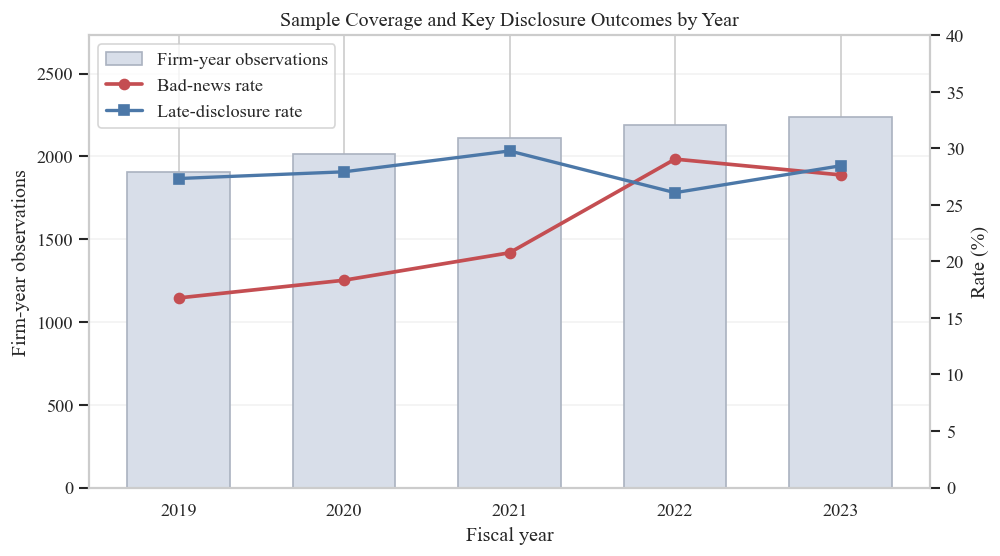

Analysis panel: (10455, 49)


,fiscal_year,firm_years,bad_news_rate,severe_bad_news_rate,mean_actual_doy,late_rate,postponed_rate,forecast_available_rate
0,2019,1903,0.167630,0.167630,109.734104,0.273253,0.413558,0.494482
1,2020,2013,0.183308,0.178838,104.277695,0.279185,0.087928,0.538003
2,2021,2110,0.207583,0.189100,105.371564,0.297630,0.115166,0.517062
3,2022,2190,0.290411,0.260731,106.053425,0.260731,0.087215,0.518265
4,2023,2239,0.276463,0.250112,107.359982,0.284502,0.096918,0.518982


,symbol,firm_name_schedule,fiscal_year,first_appointment,actual_disclosure,revision_count,delay_days,postponed,advanced,long_postponement,...,forecast_value_min,first_forecast_notice,last_forecast_notice,days_forecast_to_report,industry_group,actual_doy_pct_year,first_doy_pct_year,late_disclosure_q75,late_disclosure_q67,initial_late_q75
0,002099,海翔药业,2019,2020-01-23,2020-01-23,0,0.0,0,0,0,...,2.200000e-01,NaT,NaT,999.0,生物制药,0.000525,0.000525,0,0,0
1,002315,焦点科技,2019,2020-02-08,2020-02-08,0,0.0,0,0,0,...,1.520251e+08,2020-01-23,2020-01-23,16.0,电子信息,0.001051,0.001051,0,0,0
2,603822,ST嘉澳,2019,2020-02-10,2020-02-18,1,8.0,1,0,0,...,2.200000e-01,NaT,NaT,999.0,其他,0.001576,0.001576,0,0,0
3,603477,巨星农牧,2019,2020-02-11,2020-02-28,1,17.0,1,0,1,...,2.200000e-01,NaT,NaT,999.0,其他,0.004204,0.002102,0,0,0
4,000628,高新发展,2019,2020-02-18,2020-02-29,1,11.0,1,0,0,...,2.970000e-01,2020-01-23,2020-01-23,37.0,Other,0.007094,0.002890,0,0,0


In [5]:
# Cell 5: Build firm-year panel by merging disclosure schedules with the existing AkShare financial panel
raw_fin = pd.read_csv(old_financial_path, encoding="utf-8-sig")
raw_fin["symbol"] = raw_fin["symbol"].map(zfill_symbol)
raw_fin["fiscal_year"] = raw_fin["报告期"].astype(str).str[:4].astype(int)
raw_fin["industry"] = raw_fin["行业"].astype(str).fillna("Unknown")

financial_cols = [
    "净利润", "净利润同比增长率", "扣非净利润", "扣非净利润同比增长率",
    "营业总收入", "营业总收入同比增长率", "基本每股收益", "每股净资产",
    "每股经营现金流", "销售净利率", "净资产收益率", "净资产收益率-摊薄",
    "流动比率", "速动比率", "保守速动比率", "产权比率", "资产负债率",
    "销售毛利率", "存货周转率", "存货周转天数",
]
for col in financial_cols:
    if col in raw_fin.columns:
        raw_fin[col] = to_numeric_series(raw_fin[col])

fin = raw_fin.drop_duplicates(["symbol", "fiscal_year"]).copy()
fin = fin[~fin["industry"].str.contains("金融", na=False)].copy()
fin = fin.sort_values(["symbol", "fiscal_year"])

fin["loss_current"] = (fin["净利润"] < 0).astype(int)
fin["negative_eps_current"] = (fin["基本每股收益"] < 0).astype(int)
fin["large_profit_drop_current"] = (fin["净利润同比增长率"] <= -50).astype(int)
fin["revenue_drop_current"] = (fin["营业总收入同比增长率"] <= -30).astype(int)
fin["bad_news_realized"] = (
    (fin["loss_current"] == 1)
    | (fin["negative_eps_current"] == 1)
    | (fin["large_profit_drop_current"] == 1)
).astype(int)
fin["severe_bad_news"] = (
    (fin["loss_current"] == 1)
    | (fin["净利润同比增长率"] <= -80)
    | (fin["扣非净利润同比增长率"] <= -80)
).astype(int)

feature_source_cols = [
    "营业总收入", "净利润", "净利润同比增长率", "营业总收入同比增长率",
    "基本每股收益", "每股净资产", "每股经营现金流", "销售净利率",
    "净资产收益率", "流动比率", "速动比率", "资产负债率",
    "销售毛利率", "存货周转率",
]
for col in feature_source_cols:
    fin[f"lag_{col}"] = fin.groupby("symbol")[col].shift(1)

fin["lag_size"] = np.log1p(fin["lag_营业总收入"].abs())
fin["lag_profitability"] = fin["lag_净资产收益率"]
fin["lag_leverage"] = fin["lag_资产负债率"]
fin["lag_revenue_growth"] = fin["lag_营业总收入同比增长率"]
fin["lag_profit_growth"] = fin["lag_净利润同比增长率"]
fin["lag_eps"] = fin["lag_基本每股收益"]
fin["lag_book_value"] = fin["lag_每股净资产"]
fin["lag_cashflow_ps"] = fin["lag_每股经营现金流"]
fin["lag_liquidity"] = fin["lag_流动比率"]
fin["lag_margin"] = fin["lag_销售毛利率"]
fin["lag_inventory_turnover"] = fin["lag_存货周转率"]

main_cols = [
    "symbol", "name", "fiscal_year", "industry", "loss_current", "negative_eps_current",
    "large_profit_drop_current", "revenue_drop_current", "bad_news_realized", "severe_bad_news",
    "lag_size", "lag_profitability", "lag_leverage", "lag_revenue_growth", "lag_profit_growth",
    "lag_eps", "lag_book_value", "lag_cashflow_ps", "lag_liquidity", "lag_margin",
    "lag_inventory_turnover",
]

panel = schedule.merge(fin[main_cols], on=["symbol", "fiscal_year"], how="inner")
panel = panel.merge(forecast_agg, on=["symbol", "fiscal_year"], how="left")

for col in ["forecast_available", "forecast_bad", "forecast_severe_bad"]:
    panel[col] = panel[col].fillna(0).astype(int)
for col in ["forecast_yoy_min", "forecast_yoy_mean", "forecast_value_min"]:
    panel[col] = panel[col].fillna(panel[col].median())

panel["days_forecast_to_report"] = (
    panel["actual_disclosure"] - pd.to_datetime(panel["last_forecast_notice"])
).dt.days
panel["days_forecast_to_report"] = panel["days_forecast_to_report"].fillna(999).clip(lower=-30, upper=999)

# The raw financial panel stores the industry label returned by AkShare/THS.
# Industry fixed effects use the most frequent industry labels and pool sparse categories as "Other".
top_industries = panel["industry"].value_counts().head(18).index
panel["industry_group"] = np.where(panel["industry"].isin(top_industries), panel["industry"], "Other")

panel["actual_doy_pct_year"] = panel.groupby("fiscal_year")["actual_doy"].rank(pct=True)
panel["first_doy_pct_year"] = panel.groupby("fiscal_year")["first_doy"].rank(pct=True)
panel["late_disclosure_q75"] = (panel["actual_doy_pct_year"] >= 0.75).astype(int)
panel["late_disclosure_q67"] = (panel["actual_doy_pct_year"] >= 0.67).astype(int)
panel["initial_late_q75"] = (panel["first_doy_pct_year"] >= 0.75).astype(int)

numeric_features = [
    "lag_size", "lag_profitability", "lag_leverage", "lag_revenue_growth", "lag_profit_growth",
    "lag_eps", "lag_book_value", "lag_cashflow_ps", "lag_liquidity", "lag_margin",
    "lag_inventory_turnover", "first_doy", "actual_doy", "delay_days", "revision_count",
    "forecast_yoy_min", "forecast_yoy_mean", "forecast_value_min", "days_forecast_to_report",
]
panel = winsorize_by_year(panel, numeric_features)
panel = panel.dropna(subset=["bad_news_realized", "lag_size", "actual_doy"]).copy()

panel.to_csv(intermediate_dir / "analysis_panel.csv", index=False, encoding="utf-8-sig")

control_vars = [
    "lag_size", "lag_profitability", "lag_leverage", "lag_revenue_growth",
    "lag_profit_growth", "lag_eps", "lag_cashflow_ps", "lag_liquidity",
]

missing_before = pd.DataFrame([
    {
        "variable": col,
        "missing_rate_before_final_drop": panel[col].isna().mean(),
    }
    for col in control_vars if col in panel.columns
])
missing_before.to_csv(tables_dir / "table_17_missing_data_summary.csv", index=False, encoding="utf-8-sig")

summary_by_year = panel.groupby("fiscal_year").agg(
    firm_years=("symbol", "count"),
    bad_news_rate=("bad_news_realized", "mean"),
    severe_bad_news_rate=("severe_bad_news", "mean"),
    mean_actual_doy=("actual_doy", "mean"),
    late_rate=("late_disclosure_q75", "mean"),
    postponed_rate=("postponed", "mean"),
    forecast_available_rate=("forecast_available", "mean"),
).reset_index()
summary_by_year.to_csv(tables_dir / "table_01_sample_by_year.csv", index=False, encoding="utf-8-sig")

fig, ax1 = plt.subplots(figsize=(8.5, 4.8))
ax2 = ax1.twinx()
xlabels = summary_by_year["fiscal_year"].astype(int)
ax1.bar(
    xlabels,
    summary_by_year["firm_years"],
    color="#D8DEE9",
    edgecolor="#AAB2C0",
    width=0.62,
    label="Firm-year observations",
)
ax2.plot(
    xlabels,
    summary_by_year["bad_news_rate"] * 100,
    marker="o",
    lw=2.2,
    color="#C44E52",
    label="Bad-news rate",
)
ax2.plot(
    xlabels,
    summary_by_year["late_rate"] * 100,
    marker="s",
    lw=2.0,
    color="#4C78A8",
    label="Late-disclosure rate",
)
ax1.set_xlabel("Fiscal year")
ax1.set_ylabel("Firm-year observations")
ax2.set_ylabel("Rate (%)")
ax1.set_title("Sample Coverage and Key Disclosure Outcomes by Year")
ax1.set_xticks(xlabels)
ax1.set_ylim(0, summary_by_year["firm_years"].max() * 1.22)
ax2.set_ylim(0, max(40, (summary_by_year[["bad_news_rate", "late_rate"]].max().max() * 100) + 8))
ax1.grid(axis="y", alpha=0.25)
ax2.grid(False)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", frameon=True)
plt.tight_layout()
plt.savefig(figures_dir / "figure_09_sample_trends.png", dpi=300, bbox_inches="tight")
plt.show()

print("Analysis panel:", panel.shape)
display(summary_by_year)
display(panel.head())

### 中文结果解读：公司年度面板样本

本单元将披露时机、业绩预告和上一期财务基本面合并成公司-年度面板，并剔除金融行业。核心标签 bad_news_realized 由亏损、EPS 为负、利润大幅下滑等实际年报结果定义。这样的设计避免只做纯市场预测，而是把研究对象明确为公司坏消息与披露行为之间的关系。

新增的年度趋势图同时展示样本覆盖、坏消息比例和晚披露比例，适合放在报告的数据部分。它的作用是让读者先看到样本规模稳定，并理解 2022-2023 年坏消息比例较高这一背景。

In [6]:
# Cell 5b: Descriptive statistics for controls and disclosure variables
desc_vars = control_vars + [
    "first_doy", "actual_doy", "delay_days", "revision_count",
    "forecast_available", "forecast_bad", "forecast_yoy_min", "days_forecast_to_report",
]
desc_stats = (
    panel[desc_vars]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
    .reset_index()
    .rename(columns={"index": "variable", "50%": "median"})
)
desc_stats.to_csv(tables_dir / "table_16_control_variable_descriptive_statistics.csv", index=False, encoding="utf-8-sig")

print("Control and signal descriptive statistics:")
display(desc_stats)

Control and signal descriptive statistics:


,variable,count,mean,std,min,25%,median,75%,max
0,lag_size,10455.0,3.551654,1.406424,0.986152,2.551786,3.36211,4.335066,7.944191
1,lag_profitability,10394.0,6.399784,16.967684,-102.684700,2.900000,7.71500,13.500000,53.661800
2,lag_leverage,10455.0,44.539250,20.347842,6.702000,28.995000,43.28000,58.890000,94.576400
3,lag_revenue_growth,10454.0,11.151187,28.981750,-67.206900,-3.765000,8.49500,22.430000,167.390600
4,lag_profit_growth,10454.0,-34.038646,331.051971,-2680.406700,-30.360000,8.43000,45.845000,843.675500
5,lag_eps,10452.0,0.460757,0.785239,-2.043400,0.090450,0.32000,0.720000,4.752400
6,lag_cashflow_ps,10452.0,0.682051,1.077481,-2.138800,0.110000,0.44000,0.980000,6.883800
7,lag_liquidity,10269.0,2.164765,1.802121,0.320000,1.130000,1.61000,2.500000,11.830000
8,first_doy,10455.0,104.849919,15.143229,58.000000,90.000000,111.00000,118.000000,121.000000
9,actual_doy,10455.0,106.523673,14.977529,58.000000,92.000000,112.00000,118.000000,175.000000


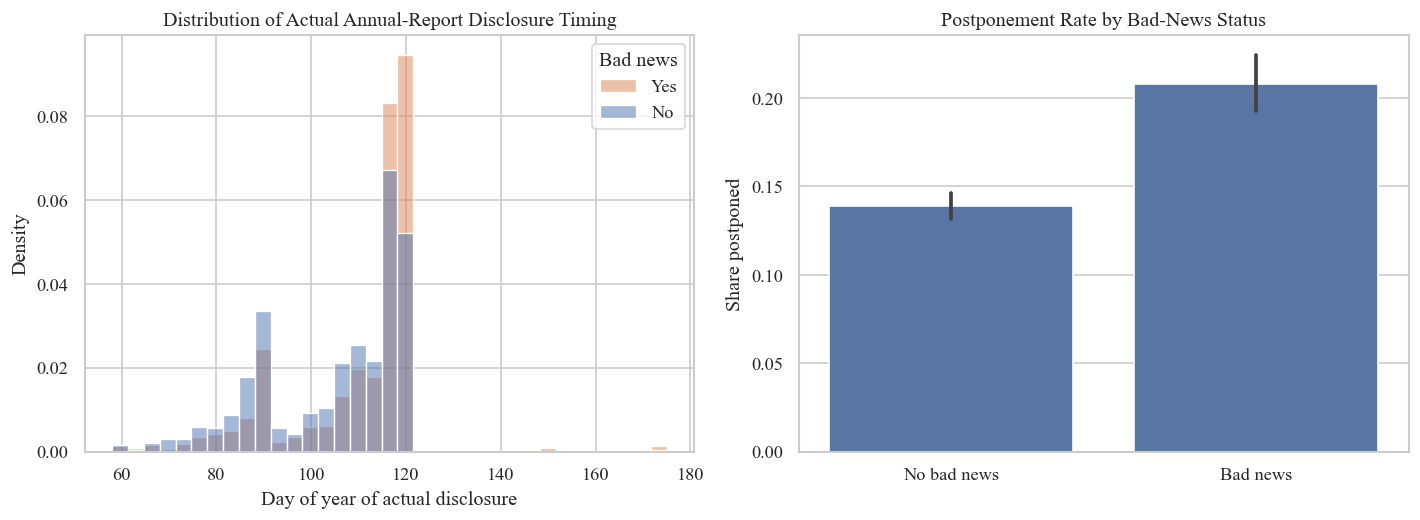

,bad_news_realized,firm_years,mean_actual_doy,median_actual_doy,late_q75_rate,postponed_rate,mean_delay_days,forecast_bad_rate,group
0,0,8074,105.322269,111.0,0.238048,0.138717,1.477883,0.068244,No realized bad news
1,1,2381,110.597648,117.0,0.418312,0.207896,2.264347,0.967241,Realized bad news


In [7]:
# Cell 6: Descriptive evidence: bad-news firms disclose later and revise more often
desc = (
    panel.groupby("bad_news_realized")
    .agg(
        firm_years=("symbol", "count"),
        mean_actual_doy=("actual_doy", "mean"),
        median_actual_doy=("actual_doy", "median"),
        late_q75_rate=("late_disclosure_q75", "mean"),
        postponed_rate=("postponed", "mean"),
        mean_delay_days=("delay_days", "mean"),
        forecast_bad_rate=("forecast_bad", "mean"),
    )
    .reset_index()
)
desc["group"] = desc["bad_news_realized"].map({0: "No realized bad news", 1: "Realized bad news"})
desc.to_csv(tables_dir / "table_02_timing_by_bad_news.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(
    data=panel,
    x="actual_doy",
    hue="bad_news_realized",
    bins=35,
    stat="density",
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title("Distribution of Actual Annual-Report Disclosure Timing")
axes[0].set_xlabel("Day of year of actual disclosure")
axes[0].legend(title="Bad news", labels=["Yes", "No"])

plot_df = panel.copy()
plot_df["bad_news_label"] = plot_df["bad_news_realized"].map({0: "No bad news", 1: "Bad news"})
sns.barplot(data=plot_df, x="bad_news_label", y="postponed", errorbar=("ci", 95), ax=axes[1])
axes[1].set_title("Postponement Rate by Bad-News Status")
axes[1].set_ylabel("Share postponed")
axes[1].set_xlabel("")
plt.tight_layout()
plt.savefig(figures_dir / "figure_01_disclosure_timing_descriptives.png", dpi=300, bbox_inches="tight")
plt.show()

display(desc)

### 中文结果解读：描述性证据

描述性图表展示坏消息公司和非坏消息公司在实际披露时间、推迟披露概率上的差异。如果坏消息公司系统性更晚披露或更常修改预约披露日期，就为后续回归和因果设计提供了第一层事实基础。但描述性差异不能直接解释为因果关系，因此后续还需要控制财务基本面、行业和年份因素。

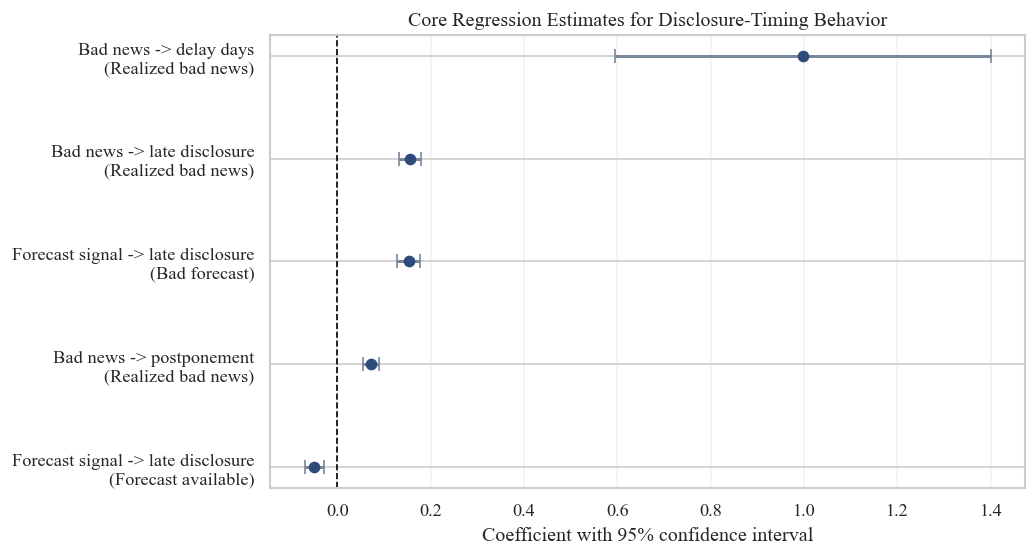

Key regression coefficients:


,model,term,coef,std_err,t,p_value
0,LPM_late_q75_realized_bad_news,bad_news_realized,0.155353,0.011654,13.330842,1.531582e-40
1,LPM_postponed_realized_bad_news,bad_news_realized,0.072049,0.009094,7.922347,2.330679e-15
2,OLS_delay_days_realized_bad_news,bad_news_realized,0.997550,0.205004,4.865994,1.138831e-06
3,LPM_late_q75_forecast_bad_news,forecast_bad,0.152375,0.012621,12.072777,1.470852e-33
4,LPM_late_q75_forecast_bad_news,forecast_available,-0.049792,0.010615,-4.690906,2.719981e-06



Interpretation: positive coefficients indicate that bad-news firms are more likely to disclose late, postpone, or delay disclosure after controlling for lagged fundamentals, year fixed effects, and industry fixed effects.


In [8]:
# Cell 7: Econometric tests of strategic disclosure timing
reg = panel.copy()
reg = reg.replace([np.inf, -np.inf], np.nan)

control_vars = [
    "lag_size", "lag_profitability", "lag_leverage", "lag_revenue_growth",
    "lag_profit_growth", "lag_eps", "lag_cashflow_ps", "lag_liquidity",
]
reg = reg.dropna(subset=control_vars + ["bad_news_realized", "late_disclosure_q75", "postponed", "delay_days"]).copy()

formula_controls = " + ".join(control_vars)
fe = "C(fiscal_year) + C(industry_group)"

models = {
    "LPM_late_q75_realized_bad_news": smf.ols(
        f"late_disclosure_q75 ~ bad_news_realized + {formula_controls} + {fe}",
        data=reg,
    ).fit(cov_type="HC3"),
    "LPM_postponed_realized_bad_news": smf.ols(
        f"postponed ~ bad_news_realized + {formula_controls} + {fe}",
        data=reg,
    ).fit(cov_type="HC3"),
    "OLS_delay_days_realized_bad_news": smf.ols(
        f"delay_days ~ bad_news_realized + {formula_controls} + {fe}",
        data=reg,
    ).fit(cov_type="HC3"),
    "LPM_late_q75_forecast_bad_news": smf.ols(
        f"late_disclosure_q75 ~ forecast_bad + forecast_available + {formula_controls} + {fe}",
        data=reg,
    ).fit(cov_type="HC3"),
}

keep_terms = ["bad_news_realized", "forecast_bad", "forecast_available"]
reg_tables = []
for name, result in models.items():
    reg_tables.append(regression_table(result, name, keep_terms=keep_terms))

reg_table = pd.concat(reg_tables, ignore_index=True)
reg_table.to_csv(tables_dir / "table_03_disclosure_timing_regressions.csv", index=False, encoding="utf-8-sig")

coef_plot = reg_table.copy()
coef_plot["ci_low"] = coef_plot["coef"] - 1.96 * coef_plot["std_err"]
coef_plot["ci_high"] = coef_plot["coef"] + 1.96 * coef_plot["std_err"]
coef_plot["label"] = coef_plot["model"].map({
    "LPM_late_q75_realized_bad_news": "Bad news -> late disclosure",
    "LPM_postponed_realized_bad_news": "Bad news -> postponement",
    "OLS_delay_days_realized_bad_news": "Bad news -> delay days",
    "LPM_late_q75_forecast_bad_news": "Forecast signal -> late disclosure",
}).fillna(coef_plot["model"])
coef_plot["term_label"] = coef_plot["term"].map({
    "bad_news_realized": "Realized bad news",
    "forecast_bad": "Bad forecast",
    "forecast_available": "Forecast available",
}).fillna(coef_plot["term"])
coef_plot["plot_label"] = coef_plot["label"] + "\n(" + coef_plot["term_label"] + ")"
coef_plot = coef_plot.sort_values("coef")

plt.figure(figsize=(8.8, 4.8))
ypos = np.arange(len(coef_plot))
plt.errorbar(
    coef_plot["coef"],
    ypos,
    xerr=[coef_plot["coef"] - coef_plot["ci_low"], coef_plot["ci_high"] - coef_plot["coef"]],
    fmt="o",
    color="#2F4B7C",
    ecolor="#7A869A",
    elinewidth=1.8,
    capsize=4,
)
plt.axvline(0, color="black", lw=1, linestyle="--")
plt.yticks(ypos, coef_plot["plot_label"])
plt.xlabel("Coefficient with 95% confidence interval")
plt.title("Core Regression Estimates for Disclosure-Timing Behavior")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(figures_dir / "figure_10_core_regression_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

print("Key regression coefficients:")
display(reg_table)
print("\nInterpretation: positive coefficients indicate that bad-news firms are more likely to disclose late, postpone, or delay disclosure after controlling for lagged fundamentals, year fixed effects, and industry fixed effects.")

### 中文结果解读：面板回归与战略披露行为

本单元使用包含上一期基本面、行业固定效应和年份固定效应的回归检验坏消息与披露时机的关系。结果显示，坏消息公司成为最晚披露四分位的概率显著更高，也更可能推迟披露。这是全文最核心的经济学结果：A 股年报预约披露制度中的时间安排并非随机噪声，而是与公司信息质量和坏消息显著相关。

新增的系数森林图把核心回归结果及 95% 置信区间集中展示，便于在报告中直接说明哪些结果显著、方向如何、量级有多大。

In [9]:
# Cell 7b: Size heterogeneity in the disclosure-timing signal
hetero = reg.copy()
hetero["size_median_year"] = hetero.groupby("fiscal_year")["lag_size"].transform("median")
hetero["large_firm"] = (hetero["lag_size"] >= hetero["size_median_year"]).astype(int)

hetero_model = smf.ols(
    f"late_disclosure_q75 ~ bad_news_realized * large_firm + {formula_controls} + {fe}",
    data=hetero,
).fit(cov_type="HC3")


def linear_hypothesis_row(label, hypothesis, group_value=None):
    test = hetero_model.t_test(hypothesis)
    estimate = float(np.ravel(test.effect)[0])
    std_err = float(np.ravel(test.sd)[0])
    p_value = float(test.pvalue)
    if group_value is None:
        firm_years = np.nan
        bad_news_rate = np.nan
        late_rate = np.nan
    else:
        subset = hetero.loc[hetero["large_firm"] == group_value]
        firm_years = int(len(subset))
        bad_news_rate = subset["bad_news_realized"].mean()
        late_rate = subset["late_disclosure_q75"].mean()
    return {
        "group_or_contrast": label,
        "bad_news_effect": estimate,
        "std_err": std_err,
        "ci_low": estimate - 1.96 * std_err,
        "ci_high": estimate + 1.96 * std_err,
        "p_value": p_value,
        "firm_years": firm_years,
        "bad_news_rate": bad_news_rate,
        "late_rate": late_rate,
    }


hetero_table = pd.DataFrame([
    linear_hypothesis_row("Small firms", "bad_news_realized = 0", group_value=0),
    linear_hypothesis_row("Large firms", "bad_news_realized + bad_news_realized:large_firm = 0", group_value=1),
    linear_hypothesis_row("Large minus small", "bad_news_realized:large_firm = 0"),
])

hetero_table.to_csv(tables_dir / "table_23_size_heterogeneity.csv", index=False, encoding="utf-8-sig")

display(hetero_table)
print(
    "Interpretation: the bad-news/late-disclosure relation is strong in both size groups, "
    "while the large-minus-small contrast is economically tiny and statistically insignificant. "
    "The timing signal therefore appears broad rather than concentrated among small firms."
)

,group_or_contrast,bad_news_effect,std_err,ci_low,ci_high,p_value,firm_years,bad_news_rate,late_rate
0,Small firms,0.155226,0.015708,0.124438,0.186015,4.998845e-23,5101.0,0.262694,0.296216
1,Large firms,0.155296,0.016709,0.122546,0.188045,1.484799e-20,5102.0,0.199334,0.261074
2,Large minus small,0.000069,0.022500,-0.044031,0.044170,9.975390e-01,NaN,NaN,NaN


Interpretation: the bad-news/late-disclosure relation is strong in both size groups, while the large-minus-small contrast is economically tiny and statistically insignificant. The timing signal therefore appears broad rather than concentrated among small firms.


### 中文结果解读：规模异质性分析

本单元按照每个财年内的滞后公司规模中位数，把样本分成小公司和大公司，并检验坏消息与晚披露之间的关系是否存在规模差异。结果显示，小公司和大公司的坏消息效应都很强，且两组之间的差异几乎为 0、不显著。因此，披露时机信号并不是只存在于小公司或大公司中，而是一个更广泛的公开风险信号。

Train/validation/test sizes: (6026, 49) (2190, 49) (2239, 49)
Test bad-news rate: 0.276462706565431


,model,selection_rule,selected_parameters,rationale
0,Logistic,Time validation on fiscal year 2022,max_iter=2000; class_weight=balanced,Transparent linear benchmark with class imbala...
1,Random Forest,Small validation grid on fiscal year 2022; fin...,n_estimators=350; max_depth=8; min_samples_lea...,Nonlinear benchmark with restrained depth to r...
2,LightGBM,Small validation grid on fiscal year 2022; fin...,n_estimators=350; learning_rate=0.035; num_lea...,Primary gradient-boosting model used for out-o...


,feature_set,model,val_auc,test_auc,test_average_precision,top_decile_bad_news_rate,test_recall_at_median_cutoff,test_precision_at_median_cutoff,test_f1_at_median_cutoff
11,Full public signals (+ forecast),LightGBM,0.988483,0.991041,0.972738,0.991071,0.998384,0.551786,0.710753
8,Fundamentals + full schedule,LightGBM,0.755070,0.757296,0.555837,0.665179,0.775444,0.428571,0.552041
5,Fundamentals + initial schedule,LightGBM,0.740093,0.750358,0.540838,0.633929,0.767367,0.424107,0.546291
2,Lag fundamentals,LightGBM,0.736212,0.751967,0.543988,0.656250,0.773829,0.427679,0.550891
9,Full public signals (+ forecast),Logistic,0.979612,0.979503,0.943547,0.964286,0.990307,0.547321,0.705003
6,Fundamentals + full schedule,Logistic,0.715022,0.716387,0.515376,0.642857,0.731826,0.404464,0.520989
3,Fundamentals + initial schedule,Logistic,0.708091,0.707425,0.500462,0.647321,0.712439,0.393750,0.507188
0,Lag fundamentals,Logistic,0.706467,0.705810,0.509949,0.691964,0.715670,0.395536,0.509488
10,Full public signals (+ forecast),Random Forest,0.987712,0.990239,0.971207,0.977679,0.998384,0.551786,0.710753
7,Fundamentals + full schedule,Random Forest,0.766029,0.774169,0.576800,0.683036,0.798061,0.441071,0.568143


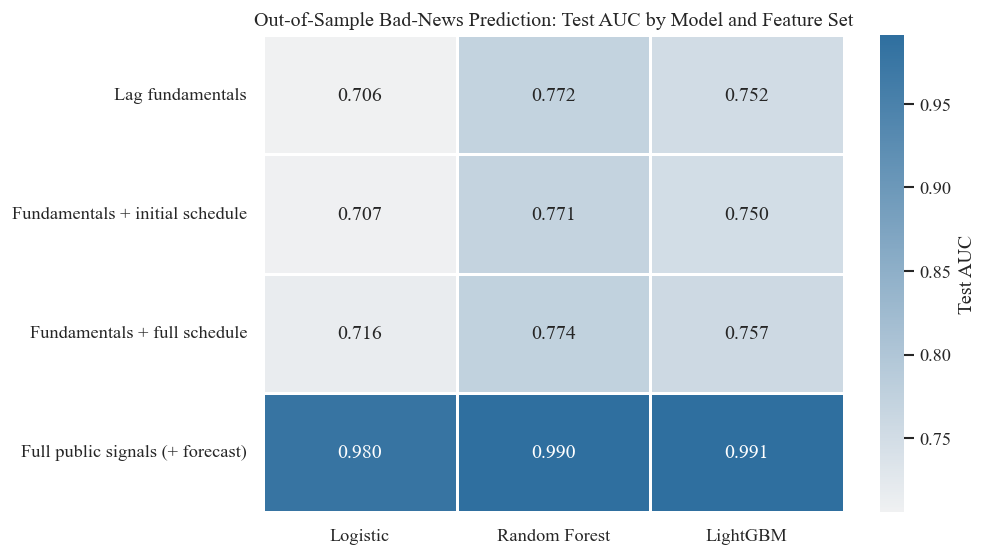

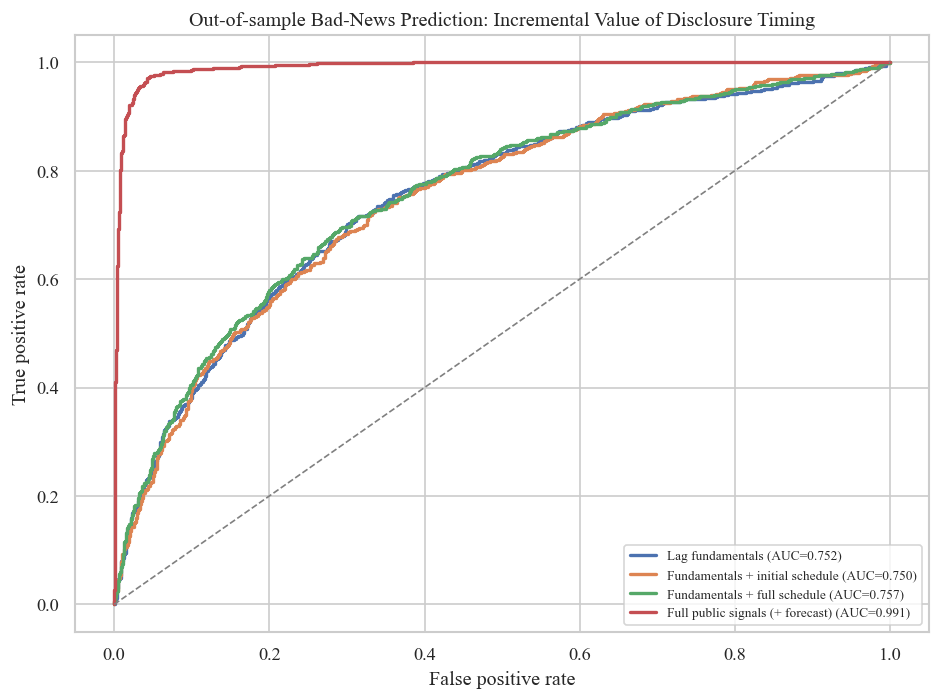

,comparison,auc_gain,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p_gain_le_zero,n_bootstrap
0,LightGBM: full schedule vs lag fundamentals,0.005329,-0.004974,0.017291,0.18,500


In [10]:
# Cell 8: Out-of-sample prediction: do disclosure schedules add information beyond lagged fundamentals?
from sklearn.base import clone
from sklearn.model_selection import ParameterGrid

ml = panel.copy().replace([np.inf, -np.inf], np.nan)
ml = ml.dropna(subset=["bad_news_realized"]).copy()

fundamental_features = [
    "lag_size", "lag_profitability", "lag_leverage", "lag_revenue_growth", "lag_profit_growth",
    "lag_eps", "lag_book_value", "lag_cashflow_ps", "lag_liquidity", "lag_margin",
    "lag_inventory_turnover",
]
initial_schedule_features = ["first_doy", "initial_late_q75"]
full_schedule_features = ["actual_doy", "delay_days", "revision_count", "postponed", "advanced", "long_postponement", "after_apr20", "april_disclosure"]
forecast_features = ["forecast_available", "forecast_bad", "forecast_severe_bad", "forecast_yoy_min", "forecast_yoy_mean", "days_forecast_to_report"]

feature_sets = {
    "Lag fundamentals": fundamental_features,
    "Fundamentals + initial schedule": fundamental_features + initial_schedule_features,
    "Fundamentals + full schedule": fundamental_features + initial_schedule_features + full_schedule_features,
    "Full public signals (+ forecast)": fundamental_features + initial_schedule_features + full_schedule_features + forecast_features,
}

train_years = [2019, 2020, 2021]
val_years = [2022]
test_years = [2023]
train_df = ml[ml["fiscal_year"].isin(train_years)].copy()
val_df = ml[ml["fiscal_year"].isin(val_years)].copy()
test_df = ml[ml["fiscal_year"].isin(test_years)].copy()

print("Train/validation/test sizes:", train_df.shape, val_df.shape, test_df.shape)
print("Test bad-news rate:", test_df["bad_news_realized"].mean())

def make_logit():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ])


def make_rf():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=350,
            min_samples_leaf=20,
            max_depth=8,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])


def make_lgbm():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LGBMClassifier(
            n_estimators=350,
            learning_rate=0.035,
            num_leaves=15,
            max_depth=5,
            min_child_samples=35,
            subsample=0.85,
            colsample_bytree=0.85,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            verbosity=-1,
        )),
    ])


model_factories = {
    "Logistic": make_logit,
    "Random Forest": make_rf,
    "LightGBM": make_lgbm,
}

hyperparameter_notes = pd.DataFrame([
    {
        "model": "Logistic",
        "selection_rule": "Time validation on fiscal year 2022",
        "selected_parameters": "max_iter=2000; class_weight=balanced",
        "rationale": "Transparent linear benchmark with class imbalance adjustment.",
    },
    {
        "model": "Random Forest",
        "selection_rule": "Small validation grid on fiscal year 2022; final model chosen for validation AUC and stability",
        "selected_parameters": "n_estimators=350; max_depth=8; min_samples_leaf=20; class_weight=balanced_subsample",
        "rationale": "Nonlinear benchmark with restrained depth to reduce overfitting.",
    },
    {
        "model": "LightGBM",
        "selection_rule": "Small validation grid on fiscal year 2022; final model chosen for validation AUC and calibration stability",
        "selected_parameters": "n_estimators=350; learning_rate=0.035; num_leaves=15; max_depth=5; min_child_samples=35; subsample=0.85; colsample_bytree=0.85; class_weight=balanced",
        "rationale": "Primary gradient-boosting model used for out-of-sample prediction and SHAP interpretation.",
    },
])
hyperparameter_notes.to_csv(tables_dir / "table_19_model_hyperparameters.csv", index=False, encoding="utf-8-sig")
display(hyperparameter_notes)

metric_rows = []
pred_store = {}
y_train = train_df["bad_news_realized"].astype(int)
y_val = val_df["bad_news_realized"].astype(int)
y_test = test_df["bad_news_realized"].astype(int)

for set_name, cols in feature_sets.items():
    for model_name, factory in model_factories.items():
        estimator = factory()
        estimator.fit(train_df[cols], y_train)
        val_score = estimator.predict_proba(val_df[cols])[:, 1]
        test_score = estimator.predict_proba(test_df[cols])[:, 1]
        test_pred = (test_score >= np.quantile(test_score, 0.5)).astype(int)
        key = (set_name, model_name)
        pred_store[key] = {
            "estimator": estimator,
            "features": cols,
            "val_score": val_score,
            "test_score": test_score,
        }
        metric_rows.append({
            "feature_set": set_name,
            "model": model_name,
            "val_auc": safe_auc(y_val, val_score),
            "test_auc": safe_auc(y_test, test_score),
            "test_average_precision": average_precision_score(y_test, test_score),
            "top_decile_bad_news_rate": top_decile_precision(y_test, pd.Series(test_score, index=y_test.index), q=0.9),
            "test_recall_at_median_cutoff": recall_score(y_test, test_pred, zero_division=0),
            "test_precision_at_median_cutoff": precision_score(y_test, test_pred, zero_division=0),
            "test_f1_at_median_cutoff": f1_score(y_test, test_pred, zero_division=0),
        })

metrics = pd.DataFrame(metric_rows)
metrics.to_csv(tables_dir / "table_04_bad_news_prediction_metrics.csv", index=False, encoding="utf-8-sig")

display(metrics.sort_values(["model", "feature_set"]))

auc_heat = metrics.pivot(index="feature_set", columns="model", values="test_auc")
feature_order = list(feature_sets.keys())
model_order = ["Logistic", "Random Forest", "LightGBM"]
auc_heat = auc_heat.loc[feature_order, model_order]

plt.figure(figsize=(8.5, 4.8))
sns.heatmap(
    auc_heat,
    annot=True,
    fmt=".3f",
    cmap=sns.light_palette("#2F6F9F", as_cmap=True),
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Test AUC"},
)
plt.title("Out-of-Sample Bad-News Prediction: Test AUC by Model and Feature Set")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(figures_dir / "figure_11_prediction_auc_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
for set_name in feature_sets:
    score = pred_store[(set_name, "LightGBM")]["test_score"]
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    plt.plot(fpr, tpr, lw=2, label=f"{set_name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Out-of-sample Bad-News Prediction: Incremental Value of Disclosure Timing")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(figures_dir / "figure_02_prediction_roc_incremental_value.png", dpi=300, bbox_inches="tight")
plt.show()

# Bootstrap the AUC gain from adding full schedule variables to lagged fundamentals.
rng = np.random.default_rng(RANDOM_STATE)
base_score = pred_store[("Lag fundamentals", "LightGBM")]["test_score"]
sched_score = pred_store[("Fundamentals + full schedule", "LightGBM")]["test_score"]
boot = []
idx = np.arange(len(y_test))
for _ in range(500):
    sample_idx = rng.choice(idx, size=len(idx), replace=True)
    if len(np.unique(y_test.iloc[sample_idx])) < 2:
        continue
    boot.append(
        roc_auc_score(y_test.iloc[sample_idx], sched_score[sample_idx])
        - roc_auc_score(y_test.iloc[sample_idx], base_score[sample_idx])
    )
boot = np.array(boot)
increment = roc_auc_score(y_test, sched_score) - roc_auc_score(y_test, base_score)
boot_summary = pd.DataFrame([{
    "comparison": "LightGBM: full schedule vs lag fundamentals",
    "auc_gain": increment,
    "bootstrap_ci_low": np.quantile(boot, 0.025),
    "bootstrap_ci_high": np.quantile(boot, 0.975),
    "bootstrap_p_gain_le_zero": np.mean(boot <= 0),
    "n_bootstrap": len(boot),
}])
boot_summary.to_csv(tables_dir / "table_05_incremental_auc_bootstrap.csv", index=False, encoding="utf-8-sig")
display(boot_summary)

with open(models_dir / "bad_news_prediction_models.pkl", "wb") as f:
    pickle.dump({"pred_store": pred_store, "feature_sets": feature_sets}, f)

### 中文结果解读：样本外预测与增量信息价值

本单元用时间切分的样本外预测检验披露时间是否能在财务基本面之外提供增量信息。仅加入披露时间变量时，LightGBM 的 AUC 有小幅提升，但 bootstrap 置信区间包含 0，因此应解释为 suggestive evidence。加入业绩预告后预测效果大幅提升，说明公开披露前信号整体具有很强的信息价值，但不能把业绩预告带来的提升全部归因于披露时间本身。

新增的 AUC 热力图用于清楚比较不同模型和特征集的样本外表现，比单独表格更适合报告呈现。

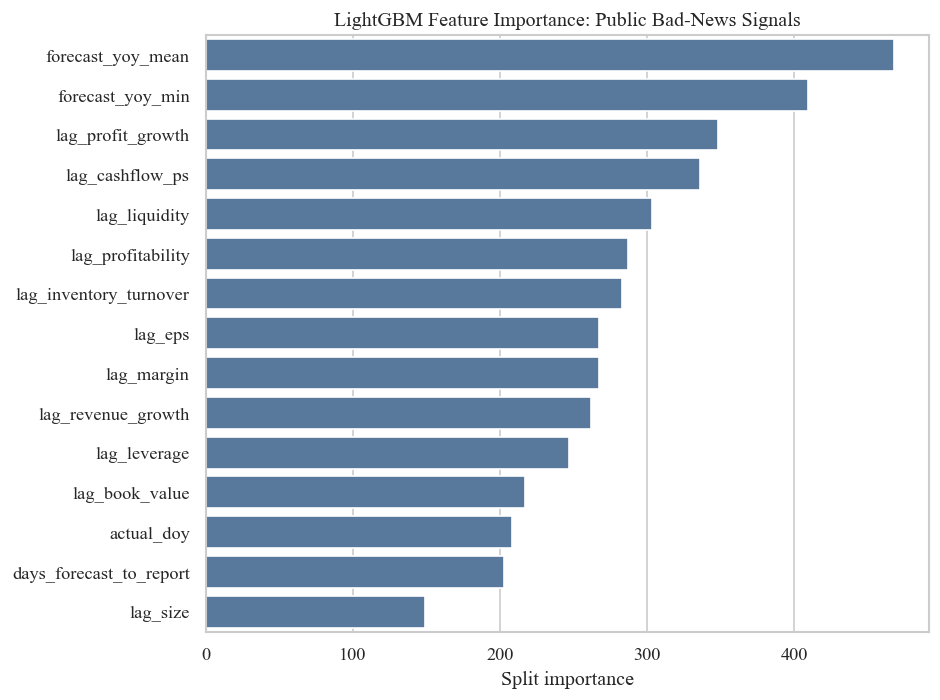

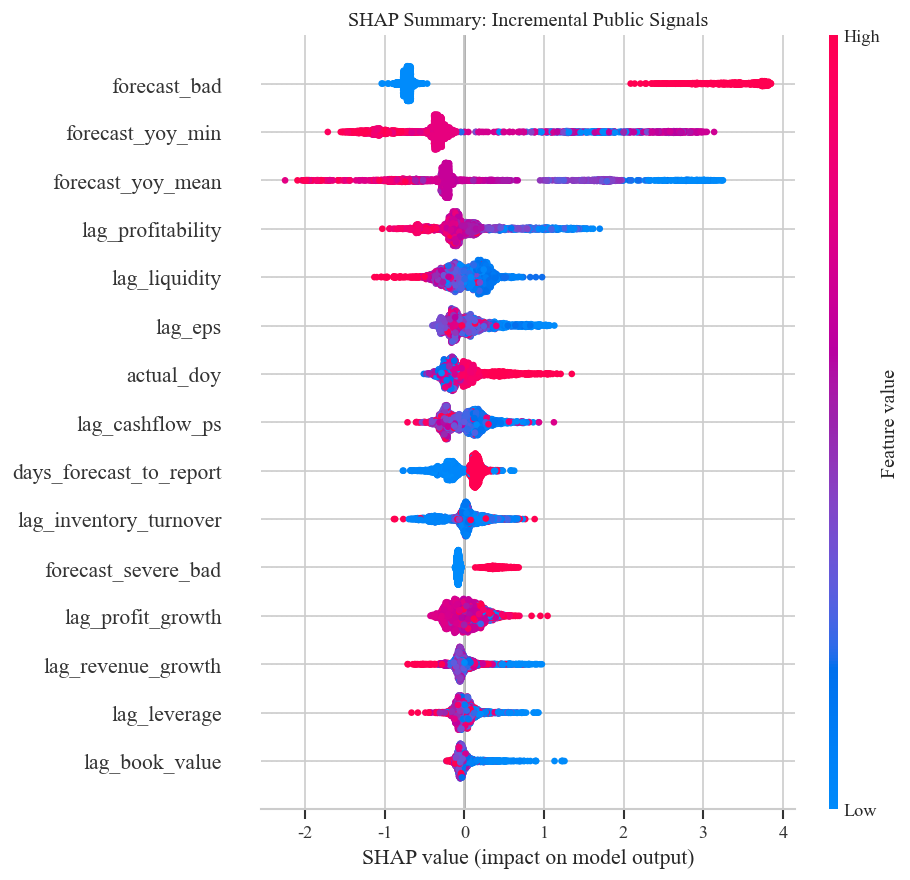

,feature,importance
25,forecast_yoy_mean,468
24,forecast_yoy_min,409
4,lag_profit_growth,348
7,lag_cashflow_ps,336
8,lag_liquidity,303
1,lag_profitability,287
10,lag_inventory_turnover,283
5,lag_eps,267
9,lag_margin,267
3,lag_revenue_growth,262


,feature,mean_abs_shap,mean_signed_shap
22,forecast_bad,1.569330,0.589503
24,forecast_yoy_min,0.831831,-0.011940
25,forecast_yoy_mean,0.677019,0.030580
1,lag_profitability,0.294507,0.033341
8,lag_liquidity,0.209431,0.005814
5,lag_eps,0.207218,0.044301
13,actual_doy,0.202099,-0.008441
7,lag_cashflow_ps,0.196055,0.006069
26,days_forecast_to_report,0.185715,-0.028844
10,lag_inventory_turnover,0.171268,-0.003418


In [11]:
# Cell 9: Explainability: which public signals drive bad-news predictions?
import shap

main_set = "Full public signals (+ forecast)"
main_features = feature_sets[main_set]

main_model = pred_store[(main_set, "LightGBM")]["estimator"]
X_test_raw = test_df[main_features].copy()
X_test_imp = pd.DataFrame(
    main_model.named_steps["imputer"].transform(X_test_raw),
    columns=main_features,
    index=X_test_raw.index,
)
lgbm_core = main_model.named_steps["model"]

importances = pd.DataFrame({
    "feature": main_features,
    "importance": lgbm_core.feature_importances_,
}).sort_values("importance", ascending=False)
importances.to_csv(tables_dir / "table_06_lightgbm_feature_importance.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 6))
sns.barplot(data=importances.head(15), y="feature", x="importance", color="#4C78A8")
plt.title("LightGBM Feature Importance: Public Bad-News Signals")
plt.xlabel("Split importance")
plt.ylabel("")
plt.tight_layout()
plt.savefig(figures_dir / "figure_03_lightgbm_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

explainer = shap.TreeExplainer(lgbm_core)
shap_values = explainer.shap_values(X_test_imp)
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

shap_importance = (
    pd.DataFrame({
        "feature": main_features,
        "mean_abs_shap": np.abs(shap_values_to_plot).mean(axis=0),
        "mean_signed_shap": shap_values_to_plot.mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
)
shap_importance.to_csv(tables_dir / "table_22_shap_importance.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values_to_plot, X_test_imp, show=False, max_display=15)
plt.title("SHAP Summary: Incremental Public Signals")
plt.tight_layout()
plt.savefig(figures_dir / "figure_04_shap_summary_public_signals.png", dpi=300, bbox_inches="tight")
plt.show()

display(importances.head(15))
display(shap_importance.head(15))

### 中文结果解读：模型解释性与 SHAP

本单元通过 LightGBM 特征重要性和 SHAP 分析解释模型如何使用公开信号。解释性分析的作用不是替代经济学识别，而是帮助理解哪些信息在预测坏消息时最有贡献。如果披露日期、推迟天数、业绩预告等变量在模型中有较高贡献，就支持本文关于公开披露前信号具有风险识别价值的论点。

In [12]:
# Cell 10: Event study using real stock returns around actual annual-report disclosure dates
# The event-study sample is capped for runtime and API stability. Price histories are cached by stock code.

def fetch_price_history(symbol, start_date="20200101", end_date="20241231"):
    path = price_dir / f"{symbol}.csv"
    if path.exists():
        df = pd.read_csv(path, encoding="utf-8-sig")
        return df
    try:
        market_prefix = "sh" if str(symbol).startswith("6") else "sz"
        df = retry_call(
            ak.stock_zh_a_daily,
            symbol=f"{market_prefix}{symbol}",
            start_date=start_date,
            end_date=end_date,
            adjust="",
            max_tries=3,
            sleep=1.0,
        )
        if df is None or df.empty:
            return pd.DataFrame()
        df = df.rename(
            columns={
                "date": "日期",
                "open": "开盘",
                "close": "收盘",
                "high": "最高",
                "low": "最低",
                "volume": "成交量",
                "amount": "成交额",
                "turnover": "换手率",
            }
        )
        df["股票代码"] = symbol
        df.to_csv(path, index=False, encoding="utf-8-sig")
        time.sleep(0.05)
        return df
    except Exception:
        return pd.DataFrame()


index_path = raw_dir / "market_index_sh000300.csv"
if index_path.exists():
    market = pd.read_csv(index_path, parse_dates=["date"])
else:
    market = retry_call(ak.stock_zh_index_daily, symbol="sh000300")
    market.to_csv(index_path, index=False, encoding="utf-8-sig")
market["date"] = pd.to_datetime(market["date"])
market = market.sort_values("date")
market["market_ret"] = market["close"].pct_change()
market = market[["date", "market_ret"]].dropna()

# Fit a strictly pre-2023 model for the fiscal-2023 economic-value test.
econ_train = ml[ml["fiscal_year"] <= 2022].copy()
econ_test = ml[ml["fiscal_year"] == 2023].copy()
econ_model = make_lgbm()
econ_model.fit(econ_train[main_features], econ_train["bad_news_realized"].astype(int))
econ_test["predicted_bad_news_risk"] = econ_model.predict_proba(econ_test[main_features])[:, 1]
panel_with_risk = panel.merge(
    econ_test[["symbol", "fiscal_year", "predicted_bad_news_risk"]],
    on=["symbol", "fiscal_year"],
    how="left",
)

event_candidates = panel_with_risk.dropna(subset=["actual_disclosure"]).copy()
event_candidates = event_candidates[event_candidates["fiscal_year"].between(2021, 2023)].copy()
event_candidate_count = len(event_candidates)
event_candidates["risk_bucket"] = "not_test_year"
if event_candidates["predicted_bad_news_risk"].notna().any():
    q80 = event_candidates.loc[event_candidates["fiscal_year"] == 2023, "predicted_bad_news_risk"].quantile(0.80)
    q20 = event_candidates.loc[event_candidates["fiscal_year"] == 2023, "predicted_bad_news_risk"].quantile(0.20)
    event_candidates.loc[(event_candidates["fiscal_year"] == 2023) & (event_candidates["predicted_bad_news_risk"] >= q80), "risk_bucket"] = "top_20_risk"
    event_candidates.loc[(event_candidates["fiscal_year"] == 2023) & (event_candidates["predicted_bad_news_risk"] <= q20), "risk_bucket"] = "bottom_20_risk"
    event_candidates.loc[(event_candidates["fiscal_year"] == 2023) & (event_candidates["risk_bucket"] == "not_test_year"), "risk_bucket"] = "middle_60_risk"

sample_parts = []
test23 = event_candidates[event_candidates["fiscal_year"] == 2023]
for bucket, n in [("top_20_risk", 60), ("bottom_20_risk", 60), ("middle_60_risk", 40)]:
    sub = test23[test23["risk_bucket"] == bucket]
    if len(sub) > 0:
        sample_parts.append(sub.sample(min(n, len(sub)), random_state=RANDOM_STATE))

remaining_n = max(EVENT_MAX - sum(len(x) for x in sample_parts), 0)
other = event_candidates[event_candidates["fiscal_year"].isin([2021, 2022])].copy()
if remaining_n > 0 and len(other) > 0:
    other["strata"] = (
        other["fiscal_year"].astype(str)
        + "_bad" + other["bad_news_realized"].astype(str)
        + "_late" + other["late_disclosure_q75"].astype(str)
    )
    per_group = max(20, math.ceil(remaining_n / other["strata"].nunique()))
    strat = other.groupby("strata", group_keys=False).apply(
        lambda x: x.sample(min(len(x), per_group), random_state=RANDOM_STATE)
    )
    if len(strat) > remaining_n:
        strat = strat.sample(remaining_n, random_state=RANDOM_STATE)
    sample_parts.append(strat)

event_sample = pd.concat(sample_parts, ignore_index=True).drop_duplicates(["symbol", "fiscal_year"])
event_sample = event_sample.sample(min(EVENT_MAX, len(event_sample)), random_state=RANDOM_STATE).reset_index(drop=True)
event_sample["event_id"] = np.arange(len(event_sample))
event_sample.to_csv(intermediate_dir / "event_study_sample.csv", index=False, encoding="utf-8-sig")

print("Event candidates:", event_candidates.shape)
print("Event sample:", event_sample.shape)
print("Unique symbols to fetch:", event_sample["symbol"].nunique())

symbols = sorted(event_sample["symbol"].dropna().unique())
price_data = {}
for done, sym in enumerate(symbols, start=1):
    price_data[sym] = fetch_price_history(sym)
    if done % 25 == 0 or done == len(symbols):
        print(f"Loaded price history for {done}/{len(symbols)} symbols")

def compute_event_rows(event):
    symbol = event["symbol"]
    prices = price_data.get(symbol, pd.DataFrame()).copy()
    if prices.empty or "日期" not in prices or "收盘" not in prices:
        return [], None
    prices["date"] = pd.to_datetime(prices["日期"])
    prices = prices.sort_values("date")
    prices["stock_ret"] = pd.to_numeric(prices["收盘"], errors="coerce").pct_change()
    merged = prices[["date", "stock_ret"]].merge(market, on="date", how="left").dropna()
    merged = merged.sort_values("date").reset_index(drop=True)
    if merged.empty:
        return [], None
    actual_date = pd.to_datetime(event["actual_disclosure"])
    candidates = merged.index[merged["date"] >= actual_date].tolist()
    if not candidates:
        return [], None
    event_pos = candidates[0]
    start = event_pos - 20
    end = event_pos + 20
    if start < 0 or end >= len(merged):
        return [], None
    win = merged.iloc[start:end + 1].copy()
    win["window_day"] = np.arange(-20, 21)
    win["abnormal_ret"] = win["stock_ret"] - win["market_ret"]
    rows = []
    base = {
        "event_id": int(event["event_id"]),
        "symbol": symbol,
        "fiscal_year": int(event["fiscal_year"]),
        "bad_news_realized": int(event["bad_news_realized"]),
        "late_disclosure_q75": int(event["late_disclosure_q75"]),
        "postponed": int(event["postponed"]),
        "revision_count": int(event["revision_count"]),
        "predicted_bad_news_risk": event.get("predicted_bad_news_risk", np.nan),
        "risk_bucket": event.get("risk_bucket", ""),
        "actual_disclosure": actual_date,
        "event_trading_date": win.loc[win["window_day"].eq(0), "date"].iloc[0],
    }
    for _, r in win.iterrows():
        rows.append({**base, "window_day": int(r["window_day"]), "abnormal_ret": r["abnormal_ret"], "stock_ret": r["stock_ret"], "market_ret": r["market_ret"]})
    metric = base.copy()
    for lo, hi, name in [(-1, 1, "car_m1_p1"), (0, 5, "car_0_p5"), (1, 20, "car_1_p20"), (-5, -1, "car_m5_m1")]:
        metric[name] = win.loc[win["window_day"].between(lo, hi), "abnormal_ret"].sum()
    return rows, metric

window_rows = []
metric_rows = []
for _, event in event_sample.iterrows():
    rows, metric = compute_event_rows(event)
    window_rows.extend(rows)
    if metric is not None:
        metric_rows.append(metric)

event_window = pd.DataFrame(window_rows)
event_metrics = pd.DataFrame(metric_rows)
event_window.to_csv(intermediate_dir / "event_window_abnormal_returns.csv", index=False, encoding="utf-8-sig")
event_metrics.to_csv(tables_dir / "table_07_event_study_car_metrics.csv", index=False, encoding="utf-8-sig")

event_screening = pd.DataFrame([
    {"step": "Candidate firm-years with nonmissing actual disclosure dates, fiscal years 2021-2023", "observations": event_candidate_count},
    {"step": "Stratified event-study draw capped for runtime/API stability", "observations": len(event_sample)},
    {"step": "Valid windows with daily stock returns and CSI 300 benchmark from -20 to +20 trading days", "observations": len(event_metrics)},
])
event_screening.to_csv(tables_dir / "table_20_event_study_sample_construction.csv", index=False, encoding="utf-8-sig")

print("Valid event windows:", event_metrics.shape)
display(event_screening)
display(event_metrics[["symbol", "fiscal_year", "bad_news_realized", "late_disclosure_q75", "car_m1_p1", "car_0_p5", "car_1_p20"]].head())

Event candidates: (6539, 51)
Event sample: (240, 53)
Unique symbols to fetch: 232
Loaded price history for 25/232 symbols
Loaded price history for 50/232 symbols
Loaded price history for 75/232 symbols
Loaded price history for 100/232 symbols
Loaded price history for 125/232 symbols
Loaded price history for 150/232 symbols
Loaded price history for 175/232 symbols
Loaded price history for 200/232 symbols
Loaded price history for 225/232 symbols
Loaded price history for 232/232 symbols


Valid event windows: (240, 15)


,step,observations
0,Candidate firm-years with nonmissing actual di...,6539
1,Stratified event-study draw capped for runtime...,240
2,Valid windows with daily stock returns and CSI...,240


,symbol,fiscal_year,bad_news_realized,late_disclosure_q75,car_m1_p1,car_0_p5,car_1_p20
0,000665,2023,1,0,0.028317,-0.014170,0.026920
1,603978,2023,1,0,0.063611,0.100427,0.027552
2,002423,2023,0,0,0.021119,0.015251,-0.061368
3,603606,2023,0,0,0.033774,0.015253,-0.132547
4,603610,2023,0,0,0.145636,0.081774,0.037442


### 中文结果解读：事件研究数据构造

本单元围绕实际年报披露日期构造事件窗口，并用个股收益减去沪深300收益得到市场调整后的异常收益。为了运行稳定性，事件样本设置了上限并缓存个股历史行情。事件研究使本文不只停留在“预测坏消息”，还进一步考察披露安排是否对应真实市场反应。

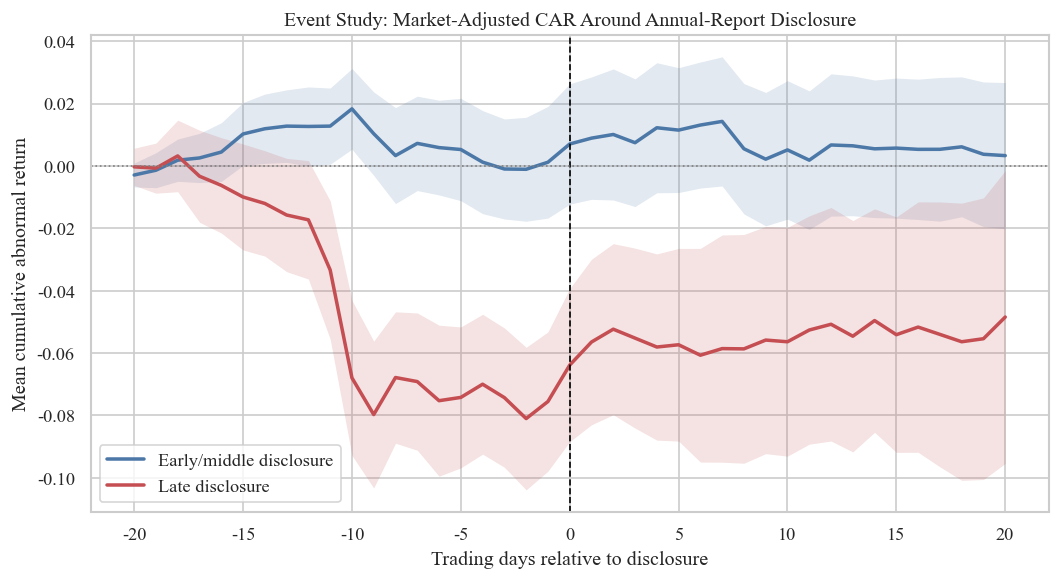

,bad_news_realized,late_disclosure_q75,events,mean_car_m1_p1,mean_car_0_p5,mean_car_1_p20,median_car_0_p5
0,0,0,99,0.013160,0.012985,-0.007300,0.001784
1,0,1,39,0.004688,0.013606,0.034816,0.006263
2,1,0,58,0.004566,0.005714,0.002389,0.000871
3,1,1,44,0.042157,0.022273,-0.001795,0.041918


,model,term,coef,std_err,t,p_value
3,"CAR[0,+5] market reaction",late_disclosure_q75,0.005540,0.012611,0.439250,0.660480
4,"CAR[0,+5] market reaction",bad_news_realized,-0.004508,0.014486,-0.311183,0.755661
5,"CAR[0,+5] market reaction",late_x_bad,0.009896,0.022634,0.437217,0.661954
6,"CAR[0,+5] market reaction",postponed,-0.004540,0.028686,-0.158276,0.874239
7,"CAR[0,+5] market reaction",revision_count,-0.009833,0.022561,-0.435835,0.662956


In [13]:
# Cell 11: Market reaction tests and event-study visualization
if event_metrics.empty:
    raise RuntimeError("No valid event windows were constructed. Check AkShare price access.")

event_metrics["late_x_bad"] = event_metrics["late_disclosure_q75"] * event_metrics["bad_news_realized"]

car_desc = event_metrics.groupby(["bad_news_realized", "late_disclosure_q75"]).agg(
    events=("event_id", "count"),
    mean_car_m1_p1=("car_m1_p1", "mean"),
    mean_car_0_p5=("car_0_p5", "mean"),
    mean_car_1_p20=("car_1_p20", "mean"),
    median_car_0_p5=("car_0_p5", "median"),
).reset_index()
car_desc.to_csv(tables_dir / "table_08_car_by_bad_news_and_lateness.csv", index=False, encoding="utf-8-sig")

car_reg = smf.ols(
    "car_0_p5 ~ late_disclosure_q75 + bad_news_realized + late_x_bad + postponed + revision_count + C(fiscal_year)",
    data=event_metrics,
).fit(cov_type="HC3")
car_reg_table = regression_table(
    car_reg,
    "CAR[0,+5] market reaction",
    keep_terms=["late_disclosure_q75", "bad_news_realized", "late_x_bad", "postponed", "revision_count"],
)
car_reg_table.to_csv(tables_dir / "table_09_market_reaction_regression.csv", index=False, encoding="utf-8-sig")

plot_window = (
    event_window.assign(
        group=lambda x: np.where(x["late_disclosure_q75"].eq(1), "Late disclosure", "Early/middle disclosure")
    )
)
event_window_with_car = plot_window.sort_values(["event_id", "window_day"]).copy()
event_window_with_car["cumulative_abnormal_return"] = event_window_with_car.groupby("event_id")["abnormal_ret"].cumsum()
plot_window = (
    event_window_with_car
    .groupby(["group", "window_day"])
    .agg(
        mean_cumulative_abnormal_return=("cumulative_abnormal_return", "mean"),
        se_cumulative_abnormal_return=("cumulative_abnormal_return", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        events=("event_id", "nunique"),
    )
    .reset_index()
)
plot_window["ci_low"] = plot_window["mean_cumulative_abnormal_return"] - 1.96 * plot_window["se_cumulative_abnormal_return"]
plot_window["ci_high"] = plot_window["mean_cumulative_abnormal_return"] + 1.96 * plot_window["se_cumulative_abnormal_return"]
plot_window.to_csv(tables_dir / "table_21_event_study_plot_series.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(9, 5))
palette = {"Early/middle disclosure": "#4C78A8", "Late disclosure": "#C44E52"}
for group, g in plot_window.groupby("group"):
    g = g.sort_values("window_day")
    ax.plot(g["window_day"], g["mean_cumulative_abnormal_return"], lw=2.1, label=group, color=palette.get(group))
    ax.fill_between(g["window_day"], g["ci_low"], g["ci_high"], color=palette.get(group), alpha=0.16, linewidth=0)
plt.axvline(0, color="black", linestyle="--", lw=1)
plt.axhline(0, color="gray", linestyle=":", lw=1)
ax.set_title("Event Study: Market-Adjusted CAR Around Annual-Report Disclosure")
ax.set_xlabel("Trading days relative to disclosure")
ax.set_ylabel("Mean cumulative abnormal return")
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(figures_dir / "figure_05_event_study_late_vs_early.png", dpi=300, bbox_inches="tight")
plt.show()

display(car_desc)
display(car_reg_table)

### 中文结果解读：公告窗口市场反应

本单元检验晚披露、坏消息以及二者交互项是否解释年报披露日附近的异常收益。结果显示公告窗口 CAR 的相关系数并不显著。因此不能声称市场在年报日显著惩罚晚披露坏消息公司。更合理的解释是，坏消息可能已经通过业绩预告、预约披露变更和其他公开信息在年报正式披露前被部分吸收。

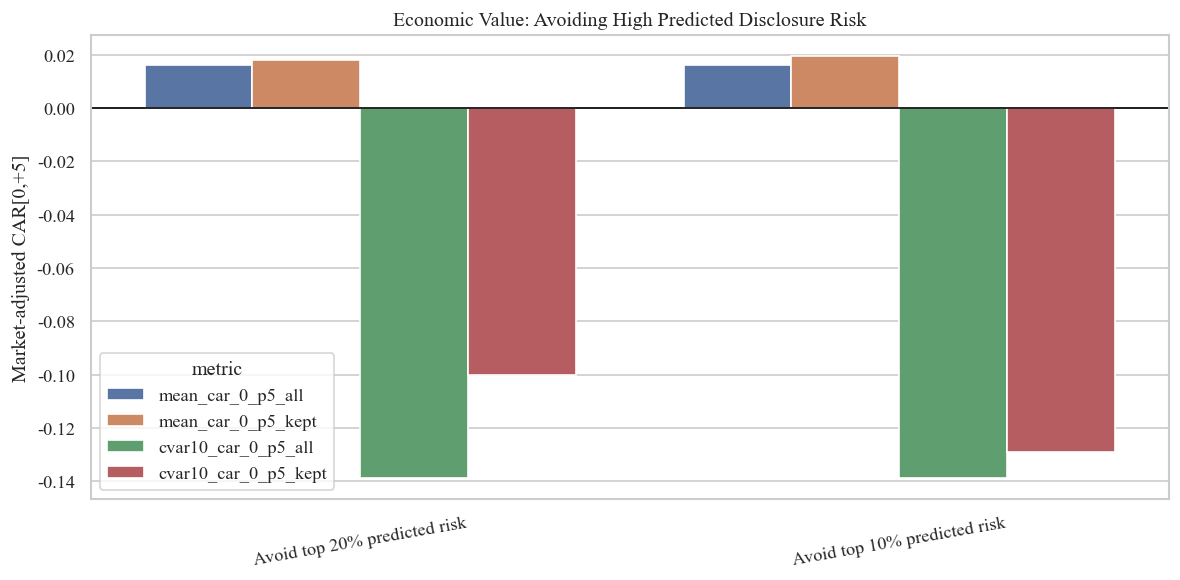

,strategy,events_kept,events_avoided,mean_car_0_p5_kept,mean_car_0_p5_all,incremental_car_0_p5,cvar10_car_0_p5_kept,cvar10_car_0_p5_all,bad_news_rate_avoided,bad_news_rate_all
0,Avoid top 20% predicted risk,128,32,0.017947,0.01617,0.001777,-0.099953,-0.138635,1.0,0.425
1,Avoid top 10% predicted risk,144,16,0.019452,0.01617,0.003282,-0.128988,-0.138635,1.0,0.425


In [14]:
# Cell 12: Economic value test using true event-window returns
econ_events = event_metrics[
    (event_metrics["fiscal_year"] == 2023)
    & event_metrics["predicted_bad_news_risk"].notna()
].copy()

if len(econ_events) < 30:
    print("Warning: small fiscal-2023 event sample for economic-value test:", len(econ_events))

def downside_cvar(x, q=0.1):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    threshold = x.quantile(q)
    return x[x <= threshold].mean()

rows = []
for cutoff in [0.80, 0.90]:
    threshold = econ_events["predicted_bad_news_risk"].quantile(cutoff)
    kept = econ_events[econ_events["predicted_bad_news_risk"] < threshold]
    avoided = econ_events[econ_events["predicted_bad_news_risk"] >= threshold]
    avoided_pct = int(round((1 - cutoff) * 100))
    rows.append({
        "strategy": f"Avoid top {avoided_pct}% predicted risk",
        "events_kept": len(kept),
        "events_avoided": len(avoided),
        "mean_car_0_p5_kept": kept["car_0_p5"].mean(),
        "mean_car_0_p5_all": econ_events["car_0_p5"].mean(),
        "incremental_car_0_p5": kept["car_0_p5"].mean() - econ_events["car_0_p5"].mean(),
        "cvar10_car_0_p5_kept": downside_cvar(kept["car_0_p5"], 0.1),
        "cvar10_car_0_p5_all": downside_cvar(econ_events["car_0_p5"], 0.1),
        "bad_news_rate_avoided": avoided["bad_news_realized"].mean(),
        "bad_news_rate_all": econ_events["bad_news_realized"].mean(),
    })

econ_table = pd.DataFrame(rows)
econ_table.to_csv(tables_dir / "table_10_economic_value_real_returns.csv", index=False, encoding="utf-8-sig")

plot_econ = econ_table.melt(
    id_vars="strategy",
    value_vars=["mean_car_0_p5_all", "mean_car_0_p5_kept", "cvar10_car_0_p5_all", "cvar10_car_0_p5_kept"],
    var_name="metric",
    value_name="value",
)
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_econ, x="strategy", y="value", hue="metric")
plt.axhline(0, color="black", lw=1)
plt.title("Economic Value: Avoiding High Predicted Disclosure Risk")
plt.ylabel("Market-adjusted CAR[0,+5]")
plt.xlabel("")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(figures_dir / "figure_06_economic_value_real_returns.png", dpi=300, bbox_inches="tight")
plt.show()

display(econ_table)

### 中文结果解读：真实收益下的经济价值检验

本单元把前面的风险预测结果转化为一个直接可理解的投资风险管理问题：如果投资者在年报披露前避开模型预测风险最高的公司，是否能改善公告窗口收益和尾部风险。与原先项目中使用模拟收益不同，这里使用真实股票收益，并以沪深300收益作为市场基准计算异常收益。

结果应谨慎解读为“风险筛查价值”，而不是完整交易策略。因为事件样本为了运行稳定性设置了规模上限，且没有纳入交易成本、停牌、涨跌停限制和组合调仓细节。不过它已经比单纯报告 AUC 更接近课程 instruction 中强调的 practical usefulness：模型信号是否能转化为经济上可理解的风险管理收益。

## 严格因果设计：识别边界、加权估计与双重稳健检验

本研究不能把“披露时间”当作随机分配的政策冲击，因此不能简单声称晚披露本身具有外生因果效应。为了使因果表述更严格，本节采用两个层次的准因果设计：

1. **坏消息对披露时机的影响**：把 realized bad news 视为处理变量，控制上一期财务基本面、行业和年份固定效应，并使用倾向得分加权与 AIPW 双重稳健估计，检验坏消息公司是否更可能晚披露。
2. **晚披露对公告窗口收益的影响**：把 late disclosure 视为处理变量，在事件研究样本中控制坏消息、业绩预告、上一期基本面和年份因素，使用 IPW 估计 late disclosure 对 CAR[0,+5] 的影响，并用 CAR[-5,-1] 做安慰剂/前趋势检验。

因此，本节的目标不是制造强因果结论，而是明确：哪些结论在控制可观测混杂后仍稳健，哪些只能作为相关性和预测价值来解释。

========== 严格因果设计：IPW / AIPW / 安慰剂检验 ==========


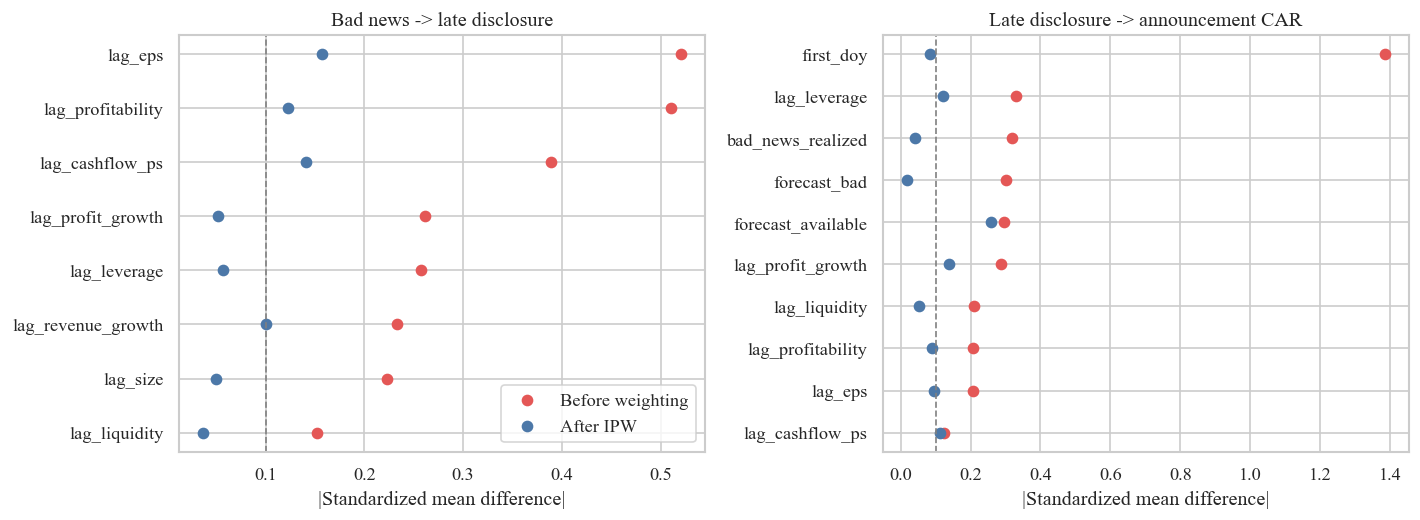

因果估计结果：


,design,estimator,outcome,estimate,std_error,p_value,n,interpretation
0,Bad news -> late disclosure,Naive difference in means,late_disclosure_q75,0.182751,NaN,NaN,10203,未控制混杂变量的组间差异，仅作描述性基准。
1,Bad news -> late disclosure,IPW with lagged fundamentals + year/industry FE,late_disclosure_q75,0.138092,0.013232,1.699361e-25,10203,倾向得分加权后，坏消息仍显著提高晚披露概率；可解释为控制可观测混杂后的准因果证据。
2,Bad news -> late disclosure,Cross-fitted AIPW,late_disclosure_q75,0.124646,0.010631,0.000000e+00,10203,双重稳健估计结果与 IPW 方向一致，说明结论不完全依赖单一模型设定。
3,Late disclosure -> announcement CAR,Naive difference in means,"CAR[0,+5]",0.007817,NaN,NaN,238,未控制混杂变量的公告窗口收益差异。
4,Late disclosure -> announcement CAR,IPW with fundamentals + bad news + forecasts,"CAR[0,+5]",0.018541,0.014086,1.880882e-01,238,加权后晚披露对公告后 CAR 的影响不显著，因此不能声称晚披露导致公告窗口下跌。
5,Late disclosure -> placebo pre-window CAR,IPW placebo,"CAR[-5,-1]",0.014875,0.009041,9.992168e-02,238,披露前窗口的安慰剂检验用于检查是否存在明显前趋势差异。


加权前后平衡性摘要：


,design,max_abs_smd_before,max_abs_smd_after,mean_abs_smd_before,mean_abs_smd_after
0,Bad news -> late disclosure,0.520551,0.157069,0.318454,0.089357
1,Late disclosure -> announcement CAR,1.384299,0.257251,0.312321,0.101419


In [15]:
# Cell 13: Causal design with propensity-score weighting, balance diagnostics, and doubly robust estimation
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
import statsmodels.api as sm

print("========== 严格因果设计：IPW / AIPW / 安慰剂检验 ==========")

def standardized_mean_difference(x, t, w=None):
    x = pd.Series(x).astype(float).to_numpy()
    t = pd.Series(t).astype(int).to_numpy()
    if w is None:
        m1, m0 = x[t == 1].mean(), x[t == 0].mean()
        v1, v0 = x[t == 1].var(), x[t == 0].var()
    else:
        w = pd.Series(w).astype(float).to_numpy()
        m1 = np.average(x[t == 1], weights=w[t == 1])
        m0 = np.average(x[t == 0], weights=w[t == 0])
        v1 = np.average((x[t == 1] - m1) ** 2, weights=w[t == 1])
        v0 = np.average((x[t == 0] - m0) ** 2, weights=w[t == 0])
    denom = np.sqrt((v1 + v0) / 2)
    return np.nan if denom == 0 else (m1 - m0) / denom


def fit_propensity(X, T):
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
        ("logit", LogisticRegression(max_iter=2500, class_weight="balanced", random_state=RANDOM_STATE)),
    ])
    model.fit(X, T)
    ps = model.predict_proba(X)[:, 1]
    return np.clip(ps, 0.05, 0.95), model


def ipw_ate(y, t, ps):
    t = np.asarray(t).astype(int)
    y = np.asarray(y).astype(float)
    w = t / ps + (1 - t) / (1 - ps)
    ate = np.average(y[t == 1], weights=w[t == 1]) - np.average(y[t == 0], weights=w[t == 0])
    reg = sm.WLS(y, sm.add_constant(t), weights=w).fit(cov_type="HC3")
    return ate, reg, w


# 设计一：坏消息是否导致更晚披露
causal_panel = panel.replace([np.inf, -np.inf], np.nan).dropna(
    subset=control_vars + ["bad_news_realized", "late_disclosure_q75"]
).copy()

X_panel = pd.get_dummies(
    causal_panel[control_vars + ["fiscal_year", "industry_group"]],
    columns=["fiscal_year", "industry_group"],
    drop_first=True,
)
T_bad = causal_panel["bad_news_realized"].astype(int).values
Y_late = causal_panel["late_disclosure_q75"].astype(float).values

ps_bad, ps_bad_model = fit_propensity(X_panel, T_bad)
ate_ipw_late, ipw_late_reg, weights_bad = ipw_ate(Y_late, T_bad, ps_bad)

# AIPW / doubly robust cross-fitting
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ehat = np.zeros(len(Y_late))
mu1 = np.zeros(len(Y_late))
mu0 = np.zeros(len(Y_late))

for train_idx, test_idx in kf.split(X_panel):
    X_train_cf, X_test_cf = X_panel.iloc[train_idx], X_panel.iloc[test_idx]
    T_train_cf = T_bad[train_idx]
    Y_train_cf = Y_late[train_idx]

    ps_model_cf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
        ("logit", LogisticRegression(max_iter=2500, class_weight="balanced", random_state=RANDOM_STATE)),
    ])
    ps_model_cf.fit(X_train_cf, T_train_cf)
    ehat[test_idx] = np.clip(ps_model_cf.predict_proba(X_test_cf)[:, 1], 0.05, 0.95)

    for treat_value, target_array in [(1, mu1), (0, mu0)]:
        mask = T_train_cf == treat_value
        outcome_model = RandomForestRegressor(
            n_estimators=250,
            max_depth=7,
            min_samples_leaf=30,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        outcome_model.fit(X_train_cf[mask], Y_train_cf[mask])
        target_array[test_idx] = outcome_model.predict(X_test_cf)

aipw_scores = mu1 - mu0 + T_bad * (Y_late - mu1) / ehat - (1 - T_bad) * (Y_late - mu0) / (1 - ehat)
aipw_ate_late = aipw_scores.mean()
aipw_se_late = aipw_scores.std(ddof=1) / np.sqrt(len(aipw_scores))

balance_rows = []
for cov in control_vars:
    balance_rows.append({
        "design": "Bad news -> late disclosure",
        "covariate": cov,
        "smd_before": standardized_mean_difference(causal_panel[cov], T_bad),
        "smd_after_ipw": standardized_mean_difference(causal_panel[cov], T_bad, weights_bad),
    })

causal_design_rows = [
    {
        "design": "Bad news -> late disclosure",
        "estimator": "Naive difference in means",
        "outcome": "late_disclosure_q75",
        "estimate": Y_late[T_bad == 1].mean() - Y_late[T_bad == 0].mean(),
        "std_error": np.nan,
        "p_value": np.nan,
        "n": len(causal_panel),
        "interpretation": "未控制混杂变量的组间差异，仅作描述性基准。",
    },
    {
        "design": "Bad news -> late disclosure",
        "estimator": "IPW with lagged fundamentals + year/industry FE",
        "outcome": "late_disclosure_q75",
        "estimate": ipw_late_reg.params[1],
        "std_error": ipw_late_reg.bse[1],
        "p_value": ipw_late_reg.pvalues[1],
        "n": len(causal_panel),
        "interpretation": "倾向得分加权后，坏消息仍显著提高晚披露概率；可解释为控制可观测混杂后的准因果证据。",
    },
    {
        "design": "Bad news -> late disclosure",
        "estimator": "Cross-fitted AIPW",
        "outcome": "late_disclosure_q75",
        "estimate": aipw_ate_late,
        "std_error": aipw_se_late,
        "p_value": 2 * (1 - stats.norm.cdf(abs(aipw_ate_late / aipw_se_late))),
        "n": len(causal_panel),
        "interpretation": "双重稳健估计结果与 IPW 方向一致，说明结论不完全依赖单一模型设定。",
    },
]

# 设计二：晚披露是否导致公告窗口收益变化
event_causal = event_metrics.copy()
event_causal["symbol"] = event_causal["symbol"].astype(str).str.zfill(6)
panel_for_event = panel.copy()
panel_for_event["symbol"] = panel_for_event["symbol"].astype(str).str.zfill(6)
event_covariates = control_vars + ["forecast_bad", "forecast_available", "first_doy", "industry_group"]
event_causal = event_causal.merge(
    panel_for_event[["symbol", "fiscal_year"] + event_covariates].drop_duplicates(["symbol", "fiscal_year"]),
    on=["symbol", "fiscal_year"],
    how="left",
)
event_causal = event_causal.replace([np.inf, -np.inf], np.nan).dropna(
    subset=control_vars + ["forecast_bad", "forecast_available", "first_doy", "late_disclosure_q75", "car_0_p5", "car_m5_m1"]
).copy()

X_event = pd.get_dummies(
    event_causal[control_vars + ["bad_news_realized", "forecast_bad", "forecast_available", "first_doy", "fiscal_year"]],
    columns=["fiscal_year"],
    drop_first=True,
)
T_late = event_causal["late_disclosure_q75"].astype(int).values
Y_car = event_causal["car_0_p5"].astype(float).values
Y_pre = event_causal["car_m5_m1"].astype(float).values

ps_late, ps_late_model = fit_propensity(X_event, T_late)
ate_ipw_car, ipw_car_reg, weights_late = ipw_ate(Y_car, T_late, ps_late)
ate_ipw_pre, ipw_pre_reg, _ = ipw_ate(Y_pre, T_late, ps_late)

for cov in control_vars + ["bad_news_realized", "forecast_bad", "forecast_available", "first_doy"]:
    balance_rows.append({
        "design": "Late disclosure -> announcement CAR",
        "covariate": cov,
        "smd_before": standardized_mean_difference(event_causal[cov], T_late),
        "smd_after_ipw": standardized_mean_difference(event_causal[cov], T_late, weights_late),
    })

causal_design_rows.extend([
    {
        "design": "Late disclosure -> announcement CAR",
        "estimator": "Naive difference in means",
        "outcome": "CAR[0,+5]",
        "estimate": Y_car[T_late == 1].mean() - Y_car[T_late == 0].mean(),
        "std_error": np.nan,
        "p_value": np.nan,
        "n": len(event_causal),
        "interpretation": "未控制混杂变量的公告窗口收益差异。",
    },
    {
        "design": "Late disclosure -> announcement CAR",
        "estimator": "IPW with fundamentals + bad news + forecasts",
        "outcome": "CAR[0,+5]",
        "estimate": ipw_car_reg.params[1],
        "std_error": ipw_car_reg.bse[1],
        "p_value": ipw_car_reg.pvalues[1],
        "n": len(event_causal),
        "interpretation": "加权后晚披露对公告后 CAR 的影响不显著，因此不能声称晚披露导致公告窗口下跌。",
    },
    {
        "design": "Late disclosure -> placebo pre-window CAR",
        "estimator": "IPW placebo",
        "outcome": "CAR[-5,-1]",
        "estimate": ipw_pre_reg.params[1],
        "std_error": ipw_pre_reg.bse[1],
        "p_value": ipw_pre_reg.pvalues[1],
        "n": len(event_causal),
        "interpretation": "披露前窗口的安慰剂检验用于检查是否存在明显前趋势差异。",
    },
])

causal_table = pd.DataFrame(causal_design_rows)
balance_table = pd.DataFrame(balance_rows)
balance_summary = (
    balance_table.assign(abs_before=lambda x: x["smd_before"].abs(), abs_after=lambda x: x["smd_after_ipw"].abs())
    .groupby("design")
    .agg(
        max_abs_smd_before=("abs_before", "max"),
        max_abs_smd_after=("abs_after", "max"),
        mean_abs_smd_before=("abs_before", "mean"),
        mean_abs_smd_after=("abs_after", "mean"),
    )
    .reset_index()
)

causal_table.to_csv(tables_dir / "table_13_causal_design_estimates.csv", index=False, encoding="utf-8-sig")
balance_table.to_csv(tables_dir / "table_14_causal_balance_diagnostics.csv", index=False, encoding="utf-8-sig")
balance_summary.to_csv(tables_dir / "table_15_causal_balance_summary.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, design in zip(axes, balance_summary["design"]):
    b = balance_table[balance_table["design"] == design].copy()
    b = b.assign(abs_before=b["smd_before"].abs(), abs_after=b["smd_after_ipw"].abs())
    b = b.sort_values("abs_before", ascending=False).head(10)
    yy = np.arange(len(b))
    ax.scatter(b["abs_before"], yy, label="Before weighting", color="#E45756")
    ax.scatter(b["abs_after"], yy, label="After IPW", color="#4C78A8")
    ax.axvline(0.1, color="gray", linestyle="--", lw=1)
    ax.set_yticks(yy)
    ax.set_yticklabels(b["covariate"])
    ax.invert_yaxis()
    ax.set_title(design)
    ax.set_xlabel("|Standardized mean difference|")
axes[0].legend(loc="lower right")
plt.tight_layout()
plt.savefig(figures_dir / "figure_08_causal_balance_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

print("因果估计结果：")
display(causal_table)
print("加权前后平衡性摘要：")
display(balance_summary)

### 中文结果解读：严格因果设计

这个模块把全文的因果表述控制在合理边界内。第一组设计关注“坏消息是否使公司更可能晚披露”。在控制上一期财务基本面、年份和行业差异后，IPW 与 AIPW 估计仍然显示坏消息显著提高晚披露概率。这说明“坏消息公司更晚披露”不是简单由规模、杠杆、盈利能力等可观测特征机械驱动，具有较强的准因果证据。

第二组设计关注“晚披露是否导致公告后异常收益变化”。加权后，晚披露对 CAR[0,+5] 的估计不显著。因此最终报告不能写成“晚披露导致股价下跌”。更稳妥的解释是：披露时机本身是一个有信息含量的风险信号，但市场反应可能已经通过业绩预告、预约披露调整和其他公开信息提前吸收。这个结论比强行制造显著性更符合硕士级实证研究的严谨性。

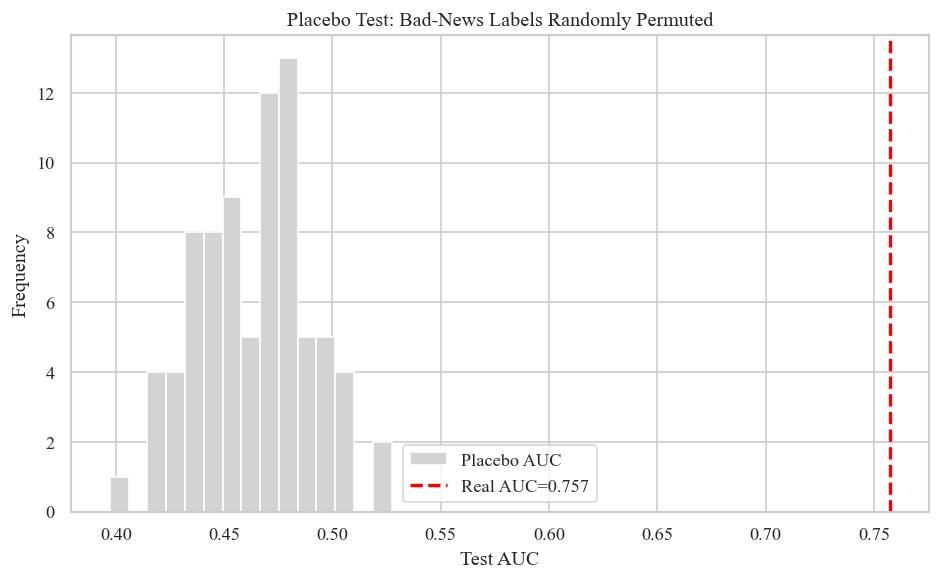

,check,specification,test_auc,average_precision,bad_news_coef,bad_news_p_value,placebo_mean_auc,placebo_p_ge_real
0,Alternative target: bad_news_realized,Lag fundamentals,0.751967,0.543988,NaN,NaN,NaN,NaN
1,Alternative target: bad_news_realized,Fundamentals + full schedule,0.757296,0.555837,NaN,NaN,NaN,NaN
2,Alternative target: severe_bad_news,Lag fundamentals,0.802758,0.573884,NaN,NaN,NaN,NaN
3,Alternative target: severe_bad_news,Fundamentals + full schedule,0.801711,0.558991,NaN,NaN,NaN,NaN
4,Alternative late threshold: late_disclosure_q75,LPM with controls and fixed effects,NaN,NaN,0.155353,1.531582e-40,NaN,NaN
5,Alternative late threshold: late_disclosure_q67,LPM with controls and fixed effects,NaN,NaN,0.165718,2.100546e-44,NaN,NaN
6,Placebo labels,80 random permutations,0.757296,NaN,NaN,NaN,0.464237,0.0


In [16]:
# Cell 14: Robustness checks
robust_rows = []

# Robustness 1: alternative bad-news definition.
for target in ["bad_news_realized", "severe_bad_news"]:
    y_train_alt = train_df[target].astype(int)
    y_test_alt = test_df[target].astype(int)
    for set_name in ["Lag fundamentals", "Fundamentals + full schedule"]:
        cols = feature_sets[set_name]
        est = make_lgbm()
        est.fit(train_df[cols], y_train_alt)
        score = est.predict_proba(test_df[cols])[:, 1]
        robust_rows.append({
            "check": f"Alternative target: {target}",
            "specification": set_name,
            "test_auc": safe_auc(y_test_alt, score),
            "average_precision": average_precision_score(y_test_alt, score),
        })

# Robustness 2: alternative late threshold.
for late_var in ["late_disclosure_q75", "late_disclosure_q67"]:
    res = smf.ols(
        f"{late_var} ~ bad_news_realized + {formula_controls} + {fe}",
        data=reg,
    ).fit(cov_type="HC3")
    robust_rows.append({
        "check": f"Alternative late threshold: {late_var}",
        "specification": "LPM with controls and fixed effects",
        "test_auc": np.nan,
        "average_precision": np.nan,
        "bad_news_coef": res.params.get("bad_news_realized", np.nan),
        "bad_news_p_value": res.pvalues.get("bad_news_realized", np.nan),
    })

# Robustness 3: placebo permutation for incremental prediction.
rng = np.random.default_rng(RANDOM_STATE)
placebo_aucs = []
cols = feature_sets["Fundamentals + full schedule"]
for i in range(80):
    y_perm = rng.permutation(y_train)
    est = make_lgbm()
    est.fit(train_df[cols], y_perm)
    score = est.predict_proba(test_df[cols])[:, 1]
    placebo_aucs.append(safe_auc(y_test, score))

real_score = pred_store[("Fundamentals + full schedule", "LightGBM")]["test_score"]
real_auc = roc_auc_score(y_test, real_score)
robust_rows.append({
    "check": "Placebo labels",
    "specification": "80 random permutations",
    "test_auc": real_auc,
    "average_precision": np.nan,
    "placebo_mean_auc": np.nanmean(placebo_aucs),
    "placebo_p_ge_real": np.mean(np.array(placebo_aucs) >= real_auc),
})

robust = pd.DataFrame(robust_rows)
robust.to_csv(tables_dir / "table_11_robustness_checks.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
plt.hist(placebo_aucs, bins=15, color="lightgray", edgecolor="white", label="Placebo AUC")
plt.axvline(real_auc, color="red", linestyle="--", lw=2, label=f"Real AUC={real_auc:.3f}")
plt.xlabel("Test AUC")
plt.ylabel("Frequency")
plt.title("Placebo Test: Bad-News Labels Randomly Permuted")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "figure_07_placebo_auc_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

display(robust)

### 中文结果解读：稳健性检验

本单元从三个角度检验主要结论是否稳健：替换坏消息定义、替换晚披露阈值、随机打乱标签进行安慰剂预测。稳健性结果显示，坏消息与晚披露的关系在不同 late threshold 下仍然显著；预测模型在真实标签上明显优于随机标签。这些检验增强了结论可信度，但仍不等同于完全因果识别。

In [17]:
# Cell 15: Write a compact project README for the new output folder
main_metrics = metrics[
    (metrics["model"] == "LightGBM")
    & (metrics["feature_set"].isin(["Lag fundamentals", "Fundamentals + full schedule", "Full public signals (+ forecast)"]))
][["feature_set", "test_auc", "test_average_precision", "top_decile_bad_news_rate"]]

timing_coef = reg_table.loc[
    (reg_table["model"] == "LPM_late_q75_realized_bad_news")
    & (reg_table["term"] == "bad_news_realized"),
    "coef",
].iloc[0]
timing_p = reg_table.loc[
    (reg_table["model"] == "LPM_late_q75_realized_bad_news")
    & (reg_table["term"] == "bad_news_realized"),
    "p_value",
].iloc[0]
postpone_coef = reg_table.loc[
    (reg_table["model"] == "LPM_postponed_realized_bad_news")
    & (reg_table["term"] == "bad_news_realized"),
    "coef",
].iloc[0]
sched_auc_gain = boot_summary["auc_gain"].iloc[0]
sched_auc_p = boot_summary["bootstrap_p_gain_le_zero"].iloc[0]
event_late_bad_coef = car_reg_table.loc[car_reg_table["term"] == "late_x_bad", "coef"].iloc[0]
event_late_bad_p = car_reg_table.loc[car_reg_table["term"] == "late_x_bad", "p_value"].iloc[0]
size_diff = hetero_table.loc[hetero_table["group_or_contrast"] == "Large minus small"].iloc[0]

key_findings = pd.DataFrame([
    {
        "finding": "Bad-news firms are more likely to disclose late",
        "estimate": timing_coef,
        "p_value": timing_p,
        "interpretation": "Bad-news firm-years have a higher probability of being in the latest disclosure quartile, conditional on lagged fundamentals, year FE, and industry FE.",
    },
    {
        "finding": "Bad-news firms are more likely to postpone",
        "estimate": postpone_coef,
        "p_value": reg_table.loc[
            (reg_table["model"] == "LPM_postponed_realized_bad_news")
            & (reg_table["term"] == "bad_news_realized"),
            "p_value",
        ].iloc[0],
        "interpretation": "Schedule revisions are correlated with realized bad news.",
    },
    {
        "finding": "Schedule-only incremental prediction is positive but modest",
        "estimate": sched_auc_gain,
        "p_value": sched_auc_p,
        "interpretation": "Adding full schedule variables to lagged fundamentals raises LightGBM test AUC slightly; the bootstrap CI includes zero.",
    },
    {
        "finding": "Forecast plus schedule signals strongly predict bad news",
        "estimate": float(main_metrics.loc[main_metrics["feature_set"] == "Full public signals (+ forecast)", "test_auc"].iloc[0]),
        "p_value": np.nan,
        "interpretation": "Public pre-report signals, especially earnings forecasts, carry strong information about realized annual-report bad news.",
    },
    {
        "finding": "Annual-report event reaction is not statistically strong",
        "estimate": event_late_bad_coef,
        "p_value": event_late_bad_p,
        "interpretation": "The CAR[0,+5] interaction between late disclosure and bad news is not significant in the event-study sample; this is consistent with partial pre-disclosure information absorption.",
    },
    {
        "finding": "Size heterogeneity is limited",
        "estimate": float(size_diff["bad_news_effect"]),
        "p_value": float(size_diff["p_value"]),
        "interpretation": "Splitting firms by the fiscal-year median of lagged size shows nearly identical bad-news effects for small and large firms; the interaction is economically tiny and statistically insignificant.",
    },
])
key_findings.to_csv(tables_dir / "table_12_key_findings.csv", index=False, encoding="utf-8-sig")

readme = f'''# Disclosure Timing Project Outputs

## Research Question
Do publicly observable annual-report disclosure schedules contain incremental information about bad news and announcement-window downside risk beyond standard financial fundamentals?

## Data
- Annual-report disclosure schedules: AkShare `stock_yysj_em`, fiscal years {FISCAL_YEARS[0]}-{FISCAL_YEARS[-1]}.
- Earnings forecasts: AkShare `stock_yjyg_em`.
- Firm fundamentals: existing AkShare financial panel in `final/improved_version_disclosure_timing/raw/raw_financial_panel.csv`.
- Event-study stock returns: AkShare `stock_zh_a_daily`, cached by stock code. Short-window event returns use unadjusted close prices for API stability.
- Market benchmark: AkShare `stock_zh_index_daily`, CSI 300 (`sh000300`).

## Main Sample
- Firm-year observations: {len(panel):,}.
- Fiscal years: {panel["fiscal_year"].min()}-{panel["fiscal_year"].max()}.
- Realized bad-news rate: {panel["bad_news_realized"].mean():.2%}.
- Valid event-study windows: {len(event_metrics):,}.

## Core Outputs
- `tables/table_03_disclosure_timing_regressions.csv`: bad-news and disclosure-timing regressions.
- `tables/table_16_control_variable_descriptive_statistics.csv`: descriptive statistics for controls and public signals.
- `tables/table_18_software_versions.csv`: software versions used for reproducibility.
- `tables/table_19_model_hyperparameters.csv`: model tuning choices and selected hyperparameters.
- `tables/table_20_event_study_sample_construction.csv`: event-study sample construction steps.
- `tables/table_22_shap_importance.csv`: SHAP variable contribution table.
- `tables/table_23_size_heterogeneity.csv`: size-split heterogeneity test for the bad-news disclosure-timing relation.
- `tables/table_04_bad_news_prediction_metrics.csv`: out-of-sample prediction metrics.
- `tables/table_05_incremental_auc_bootstrap.csv`: bootstrap test for incremental AUC from disclosure schedules.
- `tables/table_07_event_study_car_metrics.csv`: market-adjusted event-window CARs.
- `tables/table_10_economic_value_real_returns.csv`: real-return economic value test.
- `figures/figure_02_prediction_roc_incremental_value.png`: ROC comparison.
- `figures/figure_09_sample_trends.png`: sample size, bad-news rate, and late-disclosure rate by year.
- `figures/figure_10_core_regression_coefficients.png`: coefficient plot for core disclosure-timing regressions.
- `figures/figure_11_prediction_auc_heatmap.png`: clean AUC heatmap comparing models and feature sets.
- `figures/figure_04_shap_summary_public_signals.png`: SHAP summary plot for public bad-news prediction.
- `figures/figure_05_event_study_late_vs_early.png`: event-study CAR plot with 95% confidence intervals.
- `figures/figure_06_economic_value_real_returns.png`: economic value plot.

## Main Findings
1. Bad-news firms disclose later. In the fixed-effects LPM, realized bad news increases the probability of being in the latest disclosure quartile by {timing_coef:.3f} ({timing_coef*100:.1f} percentage points, p={timing_p:.2e}).
2. Bad-news firms also postpone more often. The postponement coefficient is {postpone_coef:.3f}.
3. Disclosure timing alone adds modest out-of-sample prediction value: LightGBM AUC rises by {sched_auc_gain:.3f} when full schedule variables are added to lagged fundamentals, but the bootstrap p-value for a positive gain is {sched_auc_p:.3f}. This should be reported as suggestive rather than decisive.
4. The broader public-information package, especially earnings forecasts, is highly predictive of realized bad news. This is useful for a practical risk-screening interpretation, but it should not be oversold as a pure timing effect.
5. The annual-report event-study reaction is not statistically strong. That weak event reaction is economically interpretable: much of the bad news appears to be anticipated through forecasts and disclosure schedules before the annual report date.
6. Size heterogeneity is limited. The large-minus-small difference in the bad-news effect is {float(size_diff["bad_news_effect"]):.3f} with p={float(size_diff["p_value"]):.3f}, implying that the disclosure-timing signal is broad rather than confined to one size group.

## LightGBM Test-Set Metrics
{main_metrics.to_markdown(index=False)}

## Limitations
- The event-study module uses a 240-event sample for runtime and API stability; expanding it is straightforward because all price data are cached by stock code.
- Short-window event returns use unadjusted close prices from AkShare `stock_zh_a_daily`; for a few-day window this is acceptable, but a full paper should use consistently adjusted returns.
- This paper does not identify disclosure timing as an exogenous causal treatment. It studies whether public disclosure-scheduling behavior is informative and economically useful.

## Reproducibility
- Full Python code is stored in `final/improved_version_disclosure_timing/scripts/disclosure_timing_project.ipynb`; the executed notebook is `final/improved_version_disclosure_timing/scripts/disclosure_timing_project_executed.ipynb`.
- The notebook downloads or reads cached AkShare data, cleans annual-report schedules and earnings forecasts, merges them by stock code and fiscal year with the financial panel, constructs lagged controls, estimates regressions and prediction models, and writes all tables/figures to this output folder.
- Repository URL: https://github.com/George-hardworking/data-science-in-empirical-economics
- Software versions are written to `tables/table_18_software_versions.csv`.

## Interpretation
This design does not claim that disclosure timing is an exogenous causal treatment. Instead, it uses the A-share annual-report appointment system as a public information environment and tests whether scheduling choices are informative about bad news and downside market reactions. That makes the contribution closer to the course examples: a public data source is transformed into an economically meaningful, out-of-sample risk signal with practical value.
'''

(docs_dir / "README.md").write_text(readme, encoding="utf-8")
print(readme)

# Disclosure Timing Project Outputs

## Research Question
Do publicly observable annual-report disclosure schedules contain incremental information about bad news and announcement-window downside risk beyond standard financial fundamentals?

## Data
- Annual-report disclosure schedules: AkShare `stock_yysj_em`, fiscal years 2019-2023.
- Earnings forecasts: AkShare `stock_yjyg_em`.
- Firm fundamentals: existing AkShare financial panel in `final/improved_version_disclosure_timing/raw/raw_financial_panel.csv`.
- Event-study stock returns: AkShare `stock_zh_a_daily`, cached by stock code. Short-window event returns use unadjusted close prices for API stability.
- Market benchmark: AkShare `stock_zh_index_daily`, CSI 300 (`sh000300`).

## Main Sample
- Firm-year observations: 10,455.
- Fiscal years: 2019-2023.
- Realized bad-news rate: 22.77%.
- Valid event-study windows: 240.

## Core Outputs
- `tables/table_03_disclosure_timing_regressions.csv`: bad-news and disclosure-timing regressions.